**Chapter 12 – Custom Models and Training with TensorFlow**

_This notebook contains all the sample code and solutions to the exercises in chapter 12, as well as code examples from Appendix C_

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/12_custom_models_and_training_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/12_custom_models_and_training_with_tensorflow.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [ ]:
import sys  # 导入sys模块，用于获取Python版本信息

assert sys.version_info >= (3, 7)  # 断言Python版本 >= 3.7，否则抛出AssertionError

And TensorFlow ≥ 2.8:

In [ ]:
from packaging import version  # 从packaging库导入version模块，用于比较版本号
import tensorflow as tf  # 导入TensorFlow库，简写为tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")  # 断言TensorFlow版本 >= 2.8.0

## Using TensorFlow like NumPy

### Tensors and Operations

#### Tensors

In [ ]:
t = tf.constant([[1., 2., 3.], [4., 5., 6.]])  # 创建一个2x3的浮点型常量张量（矩阵）
t  # 显示张量的内容

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [ ]:
t.shape  # 查看张量的形状，返回TensorShape([2, 3])

TensorShape([2, 3])

In [ ]:
t.dtype  # 查看张量的数据类型，返回tf.float32

tf.float32

#### Indexing

In [ ]:
t[:, 1:]  # 索引操作：取所有行，从第1列开始到最后（即取第2、3列）

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 3.],
       [5., 6.]], dtype=float32)>

In [ ]:
t[..., 1, tf.newaxis]  # 取所有行的第1列，tf.newaxis增加一个维度使结果变为列向量

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [5.]], dtype=float32)>

#### Ops

In [ ]:
t + 10  # 张量的逐元素加法：每个元素加10（广播机制）

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [ ]:
tf.square(t)  # 计算张量每个元素的平方

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)>

In [ ]:
t @ tf.transpose(t)  # 矩阵乘法：t乘以t的转置，@是矩阵乘法运算符

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[14., 32.],
       [32., 77.]], dtype=float32)>

#### Scalars

In [ ]:
tf.constant(42)  # 创建一个标量张量（0维张量），值为42

<tf.Tensor: shape=(), dtype=int32, numpy=42>

#### Keras's low-level API

You may still run across code that uses Keras's low-level API:

In [ ]:
K = tf.keras.backend  # 获取Keras后端，提供底层操作接口
K.square(K.transpose(t)) + 10  # 使用Keras后端计算：先转置t，再求平方，最后加10

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

But since Keras does not support multiple backends anymore, you should instead use TF's low-level API directly:

In [ ]:
tf.square(tf.transpose(t)) + 10  # 直接使用TF底层API：转置→平方→加10（推荐方式）

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[11., 26.],
       [14., 35.],
       [19., 46.]], dtype=float32)>

### Tensors and NumPy

In [ ]:
import numpy as np  # 导入NumPy库

a = np.array([2., 4., 5.])  # 创建一个NumPy数组
tf.constant(a)  # 将NumPy数组转换为TensorFlow常量张量

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([2., 4., 5.])>

In [ ]:
t.numpy()  # 将TensorFlow张量转换为NumPy数组

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [ ]:
np.array(t)  # 也可以用np.array()将TF张量转为NumPy数组

array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)

In [ ]:
tf.square(a)  # TF函数可以直接对NumPy数组操作，隐式转换为张量

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 4., 16., 25.])>

In [ ]:
np.square(t)  # NumPy函数也可以直接对TF张量操作，隐式转换为NumPy数组

array([[ 1.,  4.,  9.],
       [16., 25., 36.]], dtype=float32)

### Type Conversions

In [ ]:
try:
    tf.constant(2.0) + tf.constant(40)  # 尝试将float32和int32类型的张量相加
except tf.errors.InvalidArgumentError as ex:
    print(ex)  # TF不会自动做类型转换，不同类型相加会抛出InvalidArgumentError

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 


In [ ]:
try:
    tf.constant(2.0) + tf.constant(40., dtype=tf.float64)  # float32和float64也不能直接相加
except tf.errors.InvalidArgumentError as ex:
    print(ex)  # 即使都是浮点型，精度不同也会报错

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:AddV2] name: 


In [ ]:
t2 = tf.constant(40., dtype=tf.float64)  # 创建float64类型的张量
tf.constant(2.0) + tf.cast(t2, tf.float32)  # 使用tf.cast()将float64转为float32后再相加

<tf.Tensor: shape=(), dtype=float32, numpy=42.0>

### Variables

In [ ]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])  # 创建一个可变变量（Variable），与常量不同可以被修改
v  # 显示变量内容

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

In [ ]:
v.assign(2 * v)  # 使用assign()方法就地修改变量的值，将每个元素乘以2

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2.,  4.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [ ]:
v[0, 1].assign(42)  # 修改变量中第0行第1列的元素为42

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [ ]:
v[:, 2].assign([0., 1.])  # 修改所有行的第2列，分别赋值为0.0和1.0

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  0.],
       [ 8., 10.,  1.]], dtype=float32)>

In [ ]:
v.scatter_nd_update(
    indices=[[0, 0], [1, 2]], updates=[100., 200.])  # 按指定索引位置更新值：[0,0]→100, [1,2]→200

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>

In [ ]:
# 演示如何使用scatter_update()按行索引更新变量
sparse_delta = tf.IndexedSlices(values=[[1., 2., 3.], [4., 5., 6.]],  # 创建索引切片，包含要更新的值
                                indices=[1, 0])  # indices=[1,0]表示第1行用[1,2,3]更新，第0行用[4,5,6]更新
v.scatter_update(sparse_delta)  # 使用稀疏更新方式更新变量

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[4., 5., 6.],
       [1., 2., 3.]], dtype=float32)>

In [ ]:
try:
    v[1] = [7., 8., 9.]  # 不能使用直接赋值的方式修改Variable
except TypeError as ex:
    print(ex)  # 会抛出TypeError，必须使用assign()方法

'ResourceVariable' object does not support item assignment


### Strings

The code in this section and all the following sections  in appendix C

In [ ]:
tf.constant(b"hello world")  # 创建一个字节串（byte string）张量

<tf.Tensor: shape=(), dtype=string, numpy=b'hello world'>

In [ ]:
tf.constant("café")  # 创建一个Unicode字符串张量，TF会自动用UTF-8编码存储

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [ ]:
u = tf.constant([ord(c) for c in "café"])  # 将字符串"café"的每个字符转为Unicode码点（整数）
u  # 显示Unicode码点数组

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [ ]:
b = tf.strings.unicode_encode(u, "UTF-8")  # 将Unicode码点编码为UTF-8字节串
tf.strings.length(b, unit="UTF8_CHAR")  # 计算UTF-8字符串的字符数（不是字节数）

<tf.Tensor: shape=(), dtype=int32, numpy=4>

In [ ]:
tf.strings.unicode_decode(b, "UTF-8")  # 将UTF-8字节串解码为Unicode码点

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

### Other Data Structures

The code in this section is in Appendix C.

#### String arrays

In [ ]:
tf.constant(b"hello world")  # 创建字节串常量张量（附录C中的字符串数组示例）

<tf.Tensor: shape=(), dtype=string, numpy=b'hello world'>

In [ ]:
tf.constant("café")  # 创建Unicode字符串常量张量

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [ ]:
u = tf.constant([ord(c) for c in "café"])  # 将"café"每个字符转为Unicode码点
u  # 显示码点张量

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [ ]:
b = tf.strings.unicode_encode(u, "UTF-8")  # 将Unicode码点编码为UTF-8字节串
b  # 显示编码后的字节串

<tf.Tensor: shape=(), dtype=string, numpy=b'caf\xc3\xa9'>

In [ ]:
tf.strings.length(b, unit="UTF8_CHAR")  # 获取UTF-8字符串的字符数

<tf.Tensor: shape=(), dtype=int32, numpy=4>

In [ ]:
tf.strings.unicode_decode(b, "UTF-8")  # 将UTF-8字节串解码回Unicode码点

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([ 99,  97, 102, 233], dtype=int32)>

In [ ]:
p = tf.constant(["Café", "Coffee", "caffè", "咖啡"])  # 创建包含多种语言字符串的张量数组

In [ ]:
tf.strings.length(p, unit="UTF8_CHAR")  # 获取每个字符串的UTF-8字符数

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([4, 6, 5, 2], dtype=int32)>

In [ ]:
r = tf.strings.unicode_decode(p, "UTF8")  # 解码字符串数组，由于各字符串长度不同，返回不规则张量
r  # 显示不规则张量（RaggedTensor）

<tf.RaggedTensor [[67, 97, 102, 233], [67, 111, 102, 102, 101, 101],
 [99, 97, 102, 102, 232], [21654, 21857]]>

#### Ragged tensors

In [ ]:
r[1]  # 访问不规则张量的第1个元素（"Coffee"的Unicode码点）

<tf.Tensor: shape=(6,), dtype=int32, numpy=array([ 67, 111, 102, 102, 101, 101], dtype=int32)>

In [ ]:
r[1:3]  # 对不规则张量进行切片，结果仍然是不规则张量

<tf.RaggedTensor [[67, 111, 102, 102, 101, 101], [99, 97, 102, 102, 232]]>

In [ ]:
r2 = tf.ragged.constant([[65, 66], [], [67]])  # 创建一个不规则常量张量
tf.concat([r, r2], axis=0)  # 沿axis=0（行方向）拼接两个不规则张量

<tf.RaggedTensor [[67, 97, 102, 233], [67, 111, 102, 102, 101, 101],
 [99, 97, 102, 102, 232], [21654, 21857], [65, 66], [], [67]]>

In [ ]:
r3 = tf.ragged.constant([[68, 69, 70], [71], [], [72, 73]])  # 创建另一个不规则张量
print(tf.concat([r, r3], axis=1))  # 沿axis=1（列方向）拼接，将对应行的元素合并

<tf.RaggedTensor [[67, 97, 102, 233, 68, 69, 70], [67, 111, 102, 102, 101, 101, 71],
 [99, 97, 102, 102, 232], [21654, 21857, 72, 73]]>


In [ ]:
r.to_tensor()  # 将不规则张量转换为规则张量，短行用0填充补齐

<tf.Tensor: shape=(4, 6), dtype=int32, numpy=
array([[   67,    97,   102,   233,     0,     0],
       [   67,   111,   102,   102,   101,   101],
       [   99,    97,   102,   102,   232,     0],
       [21654, 21857,     0,     0,     0,     0]], dtype=int32)>

#### Sparse tensors

In [ ]:
s = tf.SparseTensor(indices=[[0, 1], [1, 0], [2, 3]],  # 稀疏张量的非零元素索引位置
                    values=[1., 2., 3.],  # 对应索引位置的值
                    dense_shape=[3, 4])  # 稀疏张量对应的稠密张量形状为3x4

In [ ]:
tf.sparse.to_dense(s)  # 将稀疏张量转换为稠密张量（用0填充空白位置）

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 1., 0., 0.],
       [2., 0., 0., 0.],
       [0., 0., 0., 3.]], dtype=float32)>

In [ ]:
s * 42.0  # 稀疏张量支持标量乘法

SparseTensor(indices=tf.Tensor(
[[0 1]
 [1 0]
 [2 3]], shape=(3, 2), dtype=int64), values=tf.Tensor([ 42.  84. 126.], shape=(3,), dtype=float32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))

In [ ]:
try:
    s + 42.0  # 稀疏张量不支持标量加法
except TypeError as ex:
    print(ex)  # 会抛出TypeError异常

unsupported operand type(s) for +: 'SparseTensor' and 'float'


In [ ]:
# 演示稀疏张量和稠密张量的矩阵乘法
s4 = tf.constant([[10., 20.], [30., 40.], [50., 60.], [70., 80.]])  # 创建4x2的稠密矩阵
tf.sparse.sparse_dense_matmul(s, s4)  # 稀疏张量(3x4)乘以稠密张量(4x2)，结果为3x2

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 30.,  40.],
       [ 20.,  40.],
       [210., 240.]], dtype=float32)>

In [ ]:
# 创建稀疏张量时，索引值必须按"阅读顺序"（行优先）排列，否则to_dense()会失败
s5 = tf.SparseTensor(indices=[[0, 2], [0, 1]],  # 错误的顺序！[0,2]应该在[0,1]之后
                     values=[1., 2.],  # 对应的值
                     dense_shape=[3, 4])  # 稠密形状
try:
    tf.sparse.to_dense(s5)  # 尝试转换为稠密张量
except tf.errors.InvalidArgumentError as ex:
    print(ex)  # 会报错，因为索引顺序不正确

{{function_node __wrapped__SparseToDense_device_/job:localhost/replica:0/task:0/device:CPU:0}} indices[1] = [0,1] is out of order. Many sparse ops require sorted indices.
    Use `tf.sparse.reorder` to create a correctly ordered copy.

 [Op:SparseToDense] name: 


2023-09-05 11:03:52.814492: W tensorflow/core/framework/op_kernel.cc:1828] OP_REQUIRES failed at sparse_to_dense_op.cc:161 : INVALID_ARGUMENT: indices[1] = [0,1] is out of order. Many sparse ops require sorted indices.
    Use `tf.sparse.reorder` to create a correctly ordered copy.




In [ ]:
# 使用tf.sparse.reorder()修复索引顺序错误的稀疏张量
s6 = tf.sparse.reorder(s5)  # 重新排列稀疏张量的索引和对应值
tf.sparse.to_dense(s6)  # 现在可以正常转换为稠密张量了

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[0., 2., 1., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]], dtype=float32)>

#### Tensor Arrays

In [ ]:
array = tf.TensorArray(dtype=tf.float32, size=3)  # 创建一个大小为3的TensorArray，元素类型为float32
array = array.write(0, tf.constant([1., 2.]))  # 在索引0处写入[1., 2.]
array = array.write(1, tf.constant([3., 10.]))  # 在索引1处写入[3., 10.]
array = array.write(2, tf.constant([5., 7.]))  # 在索引2处写入[5., 7.]
tensor1 = array.read(1)  # 读取索引1的值（读取后该位置会被清零）

In [ ]:
array.stack()  # 将TensorArray中的所有元素堆叠为一个张量（索引1处已被清零）

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 2.],
       [0., 0.],
       [5., 7.]], dtype=float32)>

In [ ]:
# 演示关闭clear_after_read，读取后不清零
array2 = tf.TensorArray(dtype=tf.float32, size=3, clear_after_read=False)  # 创建不自动清零的TensorArray
array2 = array2.write(0, tf.constant([1., 2.]))  # 写入索引0
array2 = array2.write(1, tf.constant([3., 10.]))  # 写入索引1
array2 = array2.write(2, tf.constant([5., 7.]))  # 写入索引2
tensor2 = array2.read(1)  # 读取索引1的值，由于clear_after_read=False不会被清零
array2.stack()  # 堆叠所有元素，索引1仍然保留原始值

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[ 1.,  2.],
       [ 3., 10.],
       [ 5.,  7.]], dtype=float32)>

In [ ]:
# 演示动态大小的TensorArray
array3 = tf.TensorArray(dtype=tf.float32, size=0, dynamic_size=True)  # 初始大小为0，开启动态大小
array3 = array3.write(0, tf.constant([1., 2.]))  # 动态扩展并写入
array3 = array3.write(1, tf.constant([3., 10.]))  # 写入索引1
array3 = array3.write(2, tf.constant([5., 7.]))  # 写入索引2
tensor3 = array3.read(1)  # 读取索引1
array3.stack()  # 堆叠所有元素

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 2.],
       [0., 0.],
       [5., 7.]], dtype=float32)>

#### Sets

In [ ]:
a = tf.constant([[1, 5, 9]])  # 创建集合a
b = tf.constant([[5, 6, 9, 11]])  # 创建集合b
u = tf.sets.union(a, b)  # 计算集合并集，结果是稀疏张量
u  # 显示并集结果

SparseTensor(indices=tf.Tensor(
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]], shape=(5, 2), dtype=int64), values=tf.Tensor([ 1  5  6  9 11], shape=(5,), dtype=int32), dense_shape=tf.Tensor([1 5], shape=(2,), dtype=int64))

In [ ]:
tf.sparse.to_dense(u)  # 将稀疏表示的并集结果转为稠密张量

<tf.Tensor: shape=(1, 5), dtype=int32, numpy=array([[ 1,  5,  6,  9, 11]], dtype=int32)>

In [ ]:
a = tf.constant([[1, 5, 9], [10, 0, 0]])  # 创建多行集合a（0作为填充值）
b = tf.constant([[5, 6, 9, 11], [13, 0, 0, 0]])  # 创建多行集合b
u = tf.sets.union(a, b)  # 对每一行分别计算并集
tf.sparse.to_dense(u)  # 转为稠密张量显示结果

<tf.Tensor: shape=(2, 5), dtype=int32, numpy=
array([[ 1,  5,  6,  9, 11],
       [ 0, 10, 13,  0,  0]], dtype=int32)>

In [ ]:
# 演示使用-1作为默认填充值（而非0）
a = tf.constant([[1, 5, 9], [10, -1, -1]])  # 用-1作为填充值
b = tf.constant([[5, 6, 9, 11], [13, -1, -1, -1]])  # 用-1作为填充值
u = tf.sets.union(a, b)  # 计算并集
tf.sparse.to_dense(u, default_value=-1)  # 转为稠密张量时用-1填充空白

<tf.Tensor: shape=(2, 5), dtype=int32, numpy=
array([[ 1,  5,  6,  9, 11],
       [-1, 10, 13, -1, -1]], dtype=int32)>

In [ ]:
# 演示集合差集操作
set1 = tf.constant([[2, 3, 5, 7], [7, 9, 0, 0]])  # 创建集合1
set2 = tf.constant([[4, 5, 6], [9, 10, 0]])  # 创建集合2
tf.sparse.to_dense(tf.sets.difference(set1, set2))  # 计算差集：set1中有但set2中没有的元素

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[2, 3, 7],
       [7, 0, 0]], dtype=int32)>

In [ ]:
# 演示集合交集操作
tf.sparse.to_dense(tf.sets.intersection(set1, set2))  # 计算交集：两个集合中共同的元素

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[5, 0],
       [0, 9]], dtype=int32)>

In [ ]:
# 检查set1的第0行是否包含元素5
tf.sets.size(tf.sets.intersection(set1[:1], tf.constant([[5, 0, 0, 0]]))) > 0  # 通过交集大小>0判断是否包含

<tf.Tensor: shape=(1,), dtype=bool, numpy=array([ True])>

#### Queues

In [ ]:
q = tf.queue.FIFOQueue(3, [tf.int32, tf.string], shapes=[(), ()])  # 创建FIFO队列，容量3，存储int32和string对
q.enqueue([10, b"windy"])  # 入队第一个元素
q.enqueue([15, b"sunny"])  # 入队第二个元素
q.size()  # 查看队列当前大小

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [ ]:
q.dequeue()  # 出队一个元素（先进先出），返回最先入队的元素

[<tf.Tensor: shape=(), dtype=int32, numpy=10>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'windy'>]

In [ ]:
q.enqueue_many([[13, 16], [b'cloudy', b'rainy']])  # 批量入队两个元素

In [ ]:
q.dequeue_many(3)  # 批量出队3个元素

[<tf.Tensor: shape=(3,), dtype=int32, numpy=array([15, 13, 16], dtype=int32)>,
 <tf.Tensor: shape=(3,), dtype=string, numpy=array([b'sunny', b'cloudy', b'rainy'], dtype=object)>]

## Custom loss function

In [ ]:
def huber_fn(y_true, y_pred):  # 自定义Huber损失函数
    error = y_true - y_pred  # 计算预测误差
    is_small_error = tf.abs(error) < 1  # 判断误差绝对值是否小于阈值1
    squared_loss = tf.square(error) / 2  # 小误差时使用平方损失
    linear_loss  = tf.abs(error) - 0.5  # 大误差时使用线性损失（更鲁棒，减少异常值影响）
    return tf.where(is_small_error, squared_loss, linear_loss)  # 根据条件选择不同的损失

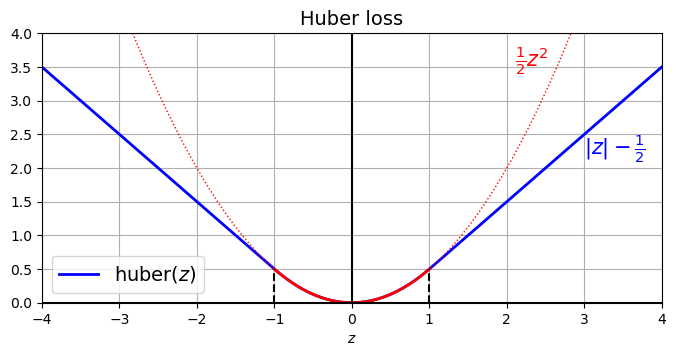

In [ ]:
# 绘制Huber损失函数的图像

import matplotlib.pyplot as plt  # 导入matplotlib绑图库

plt.figure(figsize=(8, 3.5))  # 创建8x3.5英寸的图形
z = np.linspace(-4, 4, 200)  # 在[-4, 4]之间生成200个均匀点
z_center = np.linspace(-1, 1, 200)  # 在[-1, 1]之间生成200个点（中心区域）
plt.plot(z, huber_fn(0, z), "b-", linewidth=2, label="huber($z$)")  # 绘制Huber损失曲线（蓝色实线）
plt.plot(z, z ** 2 / 2, "r:", linewidth=1)  # 绘制平方损失的完整曲线（红色虚线）
plt.plot(z_center, z_center ** 2 / 2, "r", linewidth=2)  # 中心区域的平方损失（红色实线，加粗）
plt.plot([-1, -1], [0, huber_fn(0., -1.)], "k--")  # 在z=-1处绘制垂直虚线（阈值标记）
plt.plot([1, 1], [0, huber_fn(0., 1.)], "k--")  # 在z=1处绘制垂直虚线（阈值标记）
plt.gca().axhline(y=0, color='k')  # 绘制水平坐标轴
plt.gca().axvline(x=0, color='k')  # 绘制垂直坐标轴
plt.text(2.1, 3.5, r"$\frac{1}{2}z^2$", color="r", fontsize=15)  # 标注平方损失公式
plt.text(3.0, 2.2, r"$|z| - \frac{1}{2}$", color="b", fontsize=15)  # 标注线性损失公式
plt.axis([-4, 4, 0, 4])  # 设置坐标轴范围
plt.grid(True)  # 显示网格
plt.xlabel("$z$")  # 设置x轴标签
plt.legend(fontsize=14)  # 显示图例
plt.title("Huber loss", fontsize=14)  # 设置标题
plt.show()  # 展示图形

To test our custom loss function, let's create a basic Keras model and train it on the California housing dataset:

In [ ]:
# 加载、拆分和缩放加利福尼亚住房数据集，然后创建一个简单的Keras模型

from sklearn.datasets import fetch_california_housing  # 导入加利福尼亚住房数据集
from sklearn.model_selection import train_test_split  # 导入数据集拆分工具
from sklearn.preprocessing import StandardScaler  # 导入标准缩放器

housing = fetch_california_housing()  # 加载加利福尼亚住房数据集
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target.reshape(-1, 1), random_state=42)  # 拆分为训练集和测试集
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)  # 进一步拆分出验证集

scaler = StandardScaler()  # 创建标准缩放器
X_train_scaled = scaler.fit_transform(X_train)  # 对训练集进行拟合和缩放（均值为0，标准差为1）
X_valid_scaled = scaler.transform(X_valid)  # 对验证集使用训练集的参数进行缩放
X_test_scaled = scaler.transform(X_test)  # 对测试集使用训练集的参数进行缩放

input_shape = X_train.shape[1:]  # 获取输入特征的形状（不含样本数维度）

tf.keras.utils.set_random_seed(42)  # 设置随机种子以确保可重复性
model = tf.keras.Sequential([  # 创建序贯模型
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),  # 隐藏层：30个神经元，ReLU激活，He正态初始化
    tf.keras.layers.Dense(1),  # 输出层：1个神经元（回归任务）
])

In [ ]:
model.compile(loss=huber_fn, optimizer="nadam", metrics=["mae"])  # 编译模型：使用自定义Huber损失，Nadam优化器，MAE评估指标

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,  # 训练模型2个epoch
          validation_data=(X_valid_scaled, y_valid))  # 在每个epoch后使用验证集评估

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 0.4858 - mae: 0.8357 - val_loss: 0.3479 - val_mae: 0.6527
Epoch 2/2
363/363 [==============================] - 0s 1ms/step - loss: 0.2415 - mae: 0.5419 - val_loss: 0.2630 - val_mae: 0.5473


## Saving/Loading Models with Custom Objects

In [ ]:
model.save("my_model_with_a_custom_loss.keras")  # 保存包含自定义损失函数的模型到.keras文件

INFO:tensorflow:Assets written to: my_model_with_a_custom_loss/assets


INFO:tensorflow:Assets written to: my_model_with_a_custom_loss/assets


In [ ]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss.keras",
                                   custom_objects={"huber_fn": huber_fn})  # 加载模型，需传入自定义对象映射

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,  # 继续训练加载后的模型2个epoch
          validation_data=(X_valid_scaled, y_valid))  # 使用验证集评估

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 0.2052 - mae: 0.4910 - val_loss: 0.2210 - val_mae: 0.4946
Epoch 2/2
363/363 [==============================] - 0s 1ms/step - loss: 0.1888 - mae: 0.4683 - val_loss: 0.2021 - val_mae: 0.4773


In [ ]:
def create_huber(threshold=1.0):  # 创建带有可配置阈值的Huber损失函数工厂
    def huber_fn(y_true, y_pred):  # 内部定义Huber损失函数
        error = y_true - y_pred  # 计算误差
        is_small_error = tf.abs(error) < threshold  # 判断误差是否小于阈值
        squared_loss = tf.square(error) / 2  # 小误差：平方损失
        linear_loss  = threshold * tf.abs(error) - threshold ** 2 / 2  # 大误差：线性损失（使用自定义阈值）
        return tf.where(is_small_error, squared_loss, linear_loss)  # 条件选择
    return huber_fn  # 返回闭包函数

In [ ]:
model.compile(loss=create_huber(2.0), optimizer="nadam", metrics=["mae"])  # 使用阈值为2.0的Huber损失重新编译模型

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,  # 训练2个epoch
          validation_data=(X_valid_scaled, y_valid))  # 使用验证集评估

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 0.2051 - mae: 0.4598 - val_loss: 0.2249 - val_mae: 0.4582
Epoch 2/2
363/363 [==============================] - 0s 1ms/step - loss: 0.1982 - mae: 0.4531 - val_loss: 0.2035 - val_mae: 0.4527


In [ ]:
model.save("my_model_with_a_custom_loss_threshold_2.keras")  # 保存带有自定义阈值损失的模型

INFO:tensorflow:Assets written to: my_model_with_a_custom_loss_threshold_2/assets


INFO:tensorflow:Assets written to: my_model_with_a_custom_loss_threshold_2/assets


In [ ]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_threshold_2.keras",
                                   custom_objects={"huber_fn": create_huber(2.0)})  # 加载模型，需传入相同阈值的Huber函数

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,  # 继续训练加载后的模型
          validation_data=(X_valid_scaled, y_valid))  # 验证集评估

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 0.1935 - mae: 0.4465 - val_loss: 0.2020 - val_mae: 0.4410
Epoch 2/2
363/363 [==============================] - 0s 1ms/step - loss: 0.1899 - mae: 0.4422 - val_loss: 0.1867 - val_mae: 0.4399


In [ ]:
class HuberLoss(tf.keras.losses.Loss):  # 通过继承Loss类实现自定义Huber损失（推荐方式，支持序列化）
    def __init__(self, threshold=1.0, **kwargs):  # 初始化方法，接受阈值参数
        self.threshold = threshold  # 保存阈值超参数
        super().__init__(**kwargs)  # 调用父类初始化

    def call(self, y_true, y_pred):  # 计算损失的核心方法
        error = y_true - y_pred  # 计算误差
        is_small_error = tf.abs(error) < self.threshold  # 判断是否为小误差
        squared_loss = tf.square(error) / 2  # 平方损失
        linear_loss  = self.threshold * tf.abs(error) - self.threshold**2 / 2  # 线性损失
        return tf.where(is_small_error, squared_loss, linear_loss)  # 条件选择损失类型

    def get_config(self):  # 序列化配置方法，用于保存和加载模型
        base_config = super().get_config()  # 获取父类配置
        return {**base_config, "threshold": self.threshold}  # 添加threshold到配置中

In [ ]:
# 创建另一个基础Keras模型
tf.keras.utils.set_random_seed(42)  # 设置随机种子确保可重复
model = tf.keras.Sequential([  # 创建序贯模型
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),  # 隐藏层
    tf.keras.layers.Dense(1),  # 输出层
])

In [ ]:
model.compile(loss=HuberLoss(2.), optimizer="nadam", metrics=["mae"])  # 使用HuberLoss类实例（阈值2.0）编译模型

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,  # 训练模型2个epoch
          validation_data=(X_valid_scaled, y_valid))  # 使用验证集评估

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 0.6492 - mae: 0.8468 - val_loss: 0.5093 - val_mae: 0.6723
Epoch 2/2
363/363 [==============================] - 0s 1ms/step - loss: 0.2912 - mae: 0.5552 - val_loss: 0.3715 - val_mae: 0.5683


In [ ]:
model.save("my_model_with_a_custom_loss_class.keras")  # 保存模型，自定义Loss类的配置会自动序列化

INFO:tensorflow:Assets written to: my_model_with_a_custom_loss_class/assets


INFO:tensorflow:Assets written to: my_model_with_a_custom_loss_class/assets


In [ ]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_class.keras",
                                   custom_objects={"HuberLoss": HuberLoss})  # 加载模型，传入自定义Loss类

In [ ]:
# 验证加载后的模型可以正常使用
model.fit(X_train_scaled, y_train, epochs=2,  # 继续训练
          validation_data=(X_valid_scaled, y_valid))  # 验证集评估

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 0.2416 - mae: 0.5034 - val_loss: 0.2922 - val_mae: 0.5057
Epoch 2/2
363/363 [==============================] - 0s 1ms/step - loss: 0.2173 - mae: 0.4774 - val_loss: 0.2503 - val_mae: 0.4843


In [ ]:
model.loss.threshold  # 验证阈值参数已被正确加载（应返回2.0）

2.0

## Other Custom Functions

In [ ]:
def my_softplus(z):  # 自定义softplus激活函数
    return tf.math.log(1.0 + tf.exp(z))  # softplus(z) = log(1 + exp(z))

def my_glorot_initializer(shape, dtype=tf.float32):  # 自定义Glorot（Xavier）正态初始化器
    stddev = tf.sqrt(2. / (shape[0] + shape[1]))  # 计算标准差 = sqrt(2 / (fan_in + fan_out))
    return tf.random.normal(shape, stddev=stddev, dtype=dtype)  # 返回正态分布的随机权重

def my_l1_regularizer(weights):  # 自定义L1正则化器
    return tf.reduce_sum(tf.abs(0.01 * weights))  # 返回权重绝对值之和乘以系数0.01

def my_positive_weights(weights):  # 自定义权重约束：确保权重非负
    return tf.where(weights < 0., tf.zeros_like(weights), weights)  # 将负权重置为0，等价于tf.nn.relu(weights)

In [ ]:
layer = tf.keras.layers.Dense(1, activation=my_softplus,  # 使用自定义softplus激活函数
                              kernel_initializer=my_glorot_initializer,  # 使用自定义Glorot初始化器
                              kernel_regularizer=my_l1_regularizer,  # 使用自定义L1正则化器
                              kernel_constraint=my_positive_weights)  # 使用自定义非负权重约束

In [ ]:
class MyL1Regularizer(tf.keras.regularizers.Regularizer):  # 通过继承Regularizer类实现自定义L1正则化器
    def __init__(self, factor):  # 初始化，接受正则化系数
        self.factor = factor  # 保存正则化系数

    def __call__(self, weights):  # 调用方法，计算正则化项
        return tf.reduce_sum(tf.abs(self.factor * weights))  # 返回 factor * |weights| 的总和

    def get_config(self):  # 序列化配置方法
        return {"factor": self.factor}  # 返回包含factor的配置字典

## Custom Metrics

In [ ]:
# 再次创建一个基础Keras模型用于测试自定义指标
tf.keras.utils.set_random_seed(42)  # 设置随机种子
model = tf.keras.Sequential([  # 创建序贯模型
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),  # 隐藏层
    tf.keras.layers.Dense(1),  # 输出层
])

In [ ]:
model.compile(loss="mse", optimizer="nadam", metrics=[create_huber(2.0)])  # 使用MSE损失，同时用Huber函数作为评估指标

In [ ]:
# 使用自定义指标训练模型
model.fit(X_train_scaled, y_train, epochs=2)  # 训练2个epoch

Epoch 1/2
363/363 [==============================] - 1s 844us/step - loss: 1.7474 - huber_fn: 0.6846
Epoch 2/2
363/363 [==============================] - 0s 796us/step - loss: 0.7843 - huber_fn: 0.3136


**Note**: if you use the same function as the loss and a metric, you may be surprised to see slightly different results. This is in part because the operations are not computed exactly in the same order, so there might be tiny floating point errors. More importantly, if you use sample weights or class weights, then the equations are a bit different:
* the `fit()` method keeps track of the mean of all batch losses seen so far since the start of the epoch. Each batch loss is the sum of the weighted instance losses divided by the _batch size_ (not the sum of weights, so the batch loss is _not_ the weighted mean of the losses).
* the metric since the start of the epoch is equal to the sum of weighted instance losses divided by sum of all weights seen so far. In other words, it is the weighted mean of all the instance losses. Not the same thing.

### Streaming metrics

In [ ]:
precision = tf.keras.metrics.Precision()  # 创建精确率（Precision）流式指标
precision([0, 1, 1, 1, 0, 1, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1])  # 第一批数据：传入真实标签和预测标签

<tf.Tensor: shape=(), dtype=float32, numpy=0.8>

In [ ]:
precision([0, 1, 0, 0, 1, 0, 1, 1], [1, 0, 1, 1, 0, 0, 0, 0])  # 第二批数据：流式指标会累积计算

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [ ]:
precision.result()  # 获取累积后的精确率结果

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [ ]:
precision.variables  # 查看指标内部维护的变量（true_positives和false_positives）

[<tf.Variable 'true_positives:0' shape=(1,) dtype=float32, numpy=array([4.], dtype=float32)>,
 <tf.Variable 'false_positives:0' shape=(1,) dtype=float32, numpy=array([4.], dtype=float32)>]

**Warning**: the `reset_states()` method was renamed to `reset_state()`.

In [ ]:
precision.reset_state()  # 重置指标状态（清零所有内部变量），每个epoch开始时调用

Creating a streaming metric:

**Warning**: the `add_weight()` method's argument have a different order now, so we have to specify `name="total"` and `name="count"` rather than just passing the name as the first argument.

In [ ]:
class HuberMetric(tf.keras.metrics.Metric):  # 自定义流式Huber指标类，继承自Metric基类
    def __init__(self, threshold=1.0, **kwargs):  # 初始化方法
        super().__init__(**kwargs)  # 调用父类初始化（处理基本参数如dtype）
        self.threshold = threshold  # 保存Huber阈值
        self.huber_fn = create_huber(threshold)  # 创建对应阈值的Huber损失函数
        self.total = self.add_weight(name="total", initializer="zeros")  # 添加累积损失总和变量
        self.count = self.add_weight(name="count", initializer="zeros")  # 添加样本计数变量

    def update_state(self, y_true, y_pred, sample_weight=None):  # 每批数据更新状态
        sample_metrics = self.huber_fn(y_true, y_pred)  # 计算当前批次的Huber损失
        self.total.assign_add(tf.reduce_sum(sample_metrics))  # 累加到总损失
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))  # 累加样本数

    def result(self):  # 计算最终结果
        return self.total / self.count  # 返回平均Huber损失

    def get_config(self):  # 序列化配置
        base_config = super().get_config()  # 获取父类配置
        return {**base_config, "threshold": self.threshold}  # 添加threshold到配置

**Extra material** – the rest of this section tests the `HuberMetric` class and shows another implementation subclassing `tf.keras.metrics.Mean`.

In [ ]:
m = HuberMetric(2.)  # 创建阈值为2.0的HuberMetric实例

# total = 2 * |10 - 2| - 2²/2 = 14  （大误差，使用线性损失）
# count = 1
# result = 14 / 1 = 14
m(tf.constant([[2.]]), tf.constant([[10.]]))  # 第一批：y_true=2, y_pred=10

<tf.Tensor: shape=(), dtype=float32, numpy=14.0>

In [ ]:
# total = total + (|1-0|²/2) + (2*|9.25-5| - 2²/2) = 14 + 0.5 + 6.5 = 21
# count = count + 2 = 3
# result = total / count = 21 / 3 = 7
m(tf.constant([[0.], [5.]]), tf.constant([[1.], [9.25]]))  # 第二批：两个样本，累积计算

<tf.Tensor: shape=(), dtype=float32, numpy=7.0>

In [ ]:
m.result()  # 获取当前累积的Huber指标结果（应该是7.0）

<tf.Tensor: shape=(), dtype=float32, numpy=7.0>

In [ ]:
m.variables  # 查看内部变量（total=21.0, count=3.0）

[<tf.Variable 'total:0' shape=() dtype=float32, numpy=21.0>,
 <tf.Variable 'count:0' shape=() dtype=float32, numpy=3.0>]

In [ ]:
m.reset_state()  # 重置指标状态（所有变量清零）
m.variables  # 查看重置后的变量（total=0.0, count=0.0）

[<tf.Variable 'total:0' shape=() dtype=float32, numpy=0.0>,
 <tf.Variable 'count:0' shape=() dtype=float32, numpy=0.0>]

Let's check that the `HuberMetric` class works well:

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子
model = tf.keras.Sequential([  # 创建新的序贯模型来验证HuberMetric
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),  # 隐藏层
    tf.keras.layers.Dense(1),  # 输出层
])

In [ ]:
model.compile(loss=create_huber(2.0), optimizer="nadam",
              metrics=[HuberMetric(2.0)])  # 同时使用Huber作为损失和指标，验证两者是否一致

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2)  # 训练2个epoch，观察损失和指标是否接近

Epoch 1/2
363/363 [==============================] - 1s 886us/step - loss: 0.6492 - huber_metric_1: 0.6492
Epoch 2/2
363/363 [==============================] - 0s 838us/step - loss: 0.2912 - huber_metric_1: 0.2912


In [ ]:
model.save("my_model_with_a_custom_metric.keras")  # 保存带有自定义指标的模型

INFO:tensorflow:Assets written to: my_model_with_a_custom_metric/assets


INFO:tensorflow:Assets written to: my_model_with_a_custom_metric/assets


In [ ]:
model = tf.keras.models.load_model(
    "my_model_with_a_custom_metric.keras",
    custom_objects={  # 加载模型时需要提供所有自定义对象
        "huber_fn": create_huber(2.0),  # 自定义损失函数
        "HuberMetric": HuberMetric  # 自定义指标类
    }
)

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2)  # 验证加载后的模型可正常训练

Epoch 1/2
363/363 [==============================] - 1s 916us/step - loss: 0.2416 - huber_metric_1: 0.2416
Epoch 2/2
363/363 [==============================] - 0s 859us/step - loss: 0.2173 - huber_metric_1: 0.2173


Looks like it works fine! More simply, we could have created the class like this:

In [ ]:
class HuberMetric(tf.keras.metrics.Mean):  # 更简洁的实现：继承自Mean类
    def __init__(self, threshold=1.0, name='HuberMetric', dtype=None):
        self.threshold = threshold  # 保存阈值
        self.huber_fn = create_huber(threshold)  # 创建Huber损失函数
        super().__init__(name=name, dtype=dtype)  # 调用Mean的初始化

    def update_state(self, y_true, y_pred, sample_weight=None):  # 更新状态
        metric = self.huber_fn(y_true, y_pred)  # 计算每个样本的Huber损失
        super(HuberMetric, self).update_state(metric, sample_weight)  # 委托给Mean类计算均值

    def get_config(self):  # 序列化配置
        base_config = super().get_config()  # 获取父类配置
        return {**base_config, "threshold": self.threshold}  # 添加阈值参数

This class handles shapes better, and it also supports sample weights.

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子
model = tf.keras.Sequential([  # 创建新的序贯模型
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),  # 隐藏层
    tf.keras.layers.Dense(1),  # 输出层
])

In [ ]:
model.compile(loss=tf.keras.losses.Huber(2.0), optimizer="nadam",
              weighted_metrics=[HuberMetric(2.0)])  # 使用weighted_metrics，支持样本权重

In [ ]:
np.random.seed(42)  # 设置NumPy随机种子
sample_weight = np.random.rand(len(y_train))  # 为每个训练样本生成随机权重
history = model.fit(X_train_scaled, y_train, epochs=2,
                    sample_weight=sample_weight)  # 使用样本权重训练

Epoch 1/2
363/363 [==============================] - 1s 898us/step - loss: 0.3272 - HuberMetric: 0.6594
Epoch 2/2
363/363 [==============================] - 0s 892us/step - loss: 0.1449 - HuberMetric: 0.2919


In [ ]:
(history.history["loss"][0],
 history.history["HuberMetric"][0] * sample_weight.mean())  # 比较loss和加权指标，两者应近似相等

(0.3272010087966919, 0.3272010869771911)

In [ ]:
model.save("my_model_with_a_custom_metric_v2.keras")  # 保存带有改进版自定义指标的模型

INFO:tensorflow:Assets written to: my_model_with_a_custom_metric_v2/assets


INFO:tensorflow:Assets written to: my_model_with_a_custom_metric_v2/assets


In [ ]:
model = tf.keras.models.load_model("my_model_with_a_custom_metric_v2.keras",
                                   custom_objects={"HuberMetric": HuberMetric})  # 加载模型

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2)  # 验证加载后的模型可正常训练

Epoch 1/2
363/363 [==============================] - 1s 970us/step - loss: 0.2442 - HuberMetric: 0.2442
Epoch 2/2
363/363 [==============================] - 0s 857us/step - loss: 0.2184 - HuberMetric: 0.2184


## Custom Layers

In [ ]:
exponential_layer = tf.keras.layers.Lambda(lambda x: tf.exp(x))  # 使用Lambda层创建自定义层：计算e^x

In [ ]:
# 像普通层一样作为函数使用
exponential_layer(tf.constant([-1., 0., 1.]))  # 计算e^(-1), e^0, e^1

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([0.36787945, 1.        , 2.7182817 ], dtype=float32)>

Adding an exponential layer at the output of a regression model can be useful if the values to predict are positive and with very different scales (e.g., 0.001, 10., 10000).

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子
model = tf.keras.Sequential([  # 创建带指数输出层的回归模型
    tf.keras.layers.Dense(30, activation="relu", input_shape=input_shape),  # 隐藏层：30神经元，ReLU激活
    tf.keras.layers.Dense(1),  # 线性输出层
    exponential_layer  # 指数层：确保输出为正值，适合预测正值且尺度不同的目标
])
model.compile(loss="mse", optimizer="sgd")  # 使用MSE损失和SGD优化器
model.fit(X_train_scaled, y_train, epochs=5,
          validation_data=(X_valid_scaled, y_valid))  # 训练5个epoch
model.evaluate(X_test_scaled, y_test)  # 在测试集上评估

Epoch 1/5
363/363 [==============================] - 1s 1ms/step - loss: 0.7784 - val_loss: 0.4393
Epoch 2/5
363/363 [==============================] - 0s 891us/step - loss: 0.5702 - val_loss: 0.4094
Epoch 3/5
363/363 [==============================] - 0s 1ms/step - loss: 0.4431 - val_loss: 0.3760
Epoch 4/5
363/363 [==============================] - 0s 921us/step - loss: 0.4984 - val_loss: 0.3785
Epoch 5/5
162/162 [==============================] - 0s 631us/step - loss: 0.3781


0.3781099021434784

Alternatively, it's often preferable to replace the targets with the logarithm of the targets (and use no activation function in the output layer).

In [ ]:
class MyDense(tf.keras.layers.Layer):  # 自定义全连接层，继承自Layer
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)  # 调用父类初始化
        self.units = units  # 神经元数量
        self.activation = tf.keras.activations.get(activation)  # 获取激活函数对象

    def build(self, batch_input_shape):  # 在知道输入形状后创建权重
        self.kernel = self.add_weight(
            name="kernel", shape=[batch_input_shape[-1], self.units],  # 权重矩阵形状=[输入维度, 输出维度]
            initializer="he_normal")  # 使用He正态初始化
        self.bias = self.add_weight(
            name="bias", shape=[self.units], initializer="zeros")  # 偏置向量初始化为0

    def call(self, X):  # 前向传播
        return self.activation(X @ self.kernel + self.bias)  # 线性变换后应用激活函数

    def get_config(self):  # 序列化配置
        base_config = super().get_config()  # 获取父类配置
        return {**base_config, "units": self.units,
                "activation": tf.keras.activations.serialize(self.activation)}  # 保存units和activation

In [ ]:
# 演示自定义层可以像内置层一样正常使用
tf.keras.utils.set_random_seed(42)  # 设置随机种子
model = tf.keras.Sequential([  # 构建使用MyDense层的模型
    MyDense(30, activation="relu", input_shape=input_shape),  # 自定义隐藏层
    MyDense(1)  # 自定义输出层
])
model.compile(loss="mse", optimizer="nadam")  # 编译模型
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))  # 训练并验证
model.evaluate(X_test_scaled, y_test)  # 测试评估
model.save("my_model_with_a_custom_layer.keras")  # 保存模型

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 3.1183 - val_loss: 6.9549
Epoch 2/2
162/162 [==============================] - 0s 718us/step - loss: 0.7039
INFO:tensorflow:Assets written to: my_model_with_a_custom_layer/assets


INFO:tensorflow:Assets written to: my_model_with_a_custom_layer/assets


In [ ]:
# 演示如何加载包含自定义层的模型
model = tf.keras.models.load_model("my_model_with_a_custom_layer.keras",
                                   custom_objects={"MyDense": MyDense})  # 传入自定义层映射
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))  # 继续训练验证可用性

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 0.5945 - val_loss: 0.5318
Epoch 2/2
363/363 [==============================] - 0s 1ms/step - loss: 0.4712 - val_loss: 0.5751


In [ ]:
class MyMultiLayer(tf.keras.layers.Layer):  # 自定义多输出层，输入为两个张量
    def call(self, X):  # 前向传播
        X1, X2 = X  # 解包两个输入张量
        print("X1.shape: ", X1.shape ," X2.shape: ", X2.shape)  # 打印输入形状（调试信息）
        return X1 + X2, X1 * X2, X1 / X2  # 返回三个输出：逐元素加、乘、除

Our custom layer can be called using the functional API like this:

In [ ]:
# 使用符号输入测试MyMultiLayer
inputs1 = tf.keras.layers.Input(shape=[2])  # 定义第一个符号输入，形状为[2]
inputs2 = tf.keras.layers.Input(shape=[2])  # 定义第二个符号输入，形状为[2]
MyMultiLayer()((inputs1, inputs2))  # 调用自定义层，返回三个符号输出

X1.shape:  (None, 2)  X2.shape:  (None, 2)


(<KerasTensor: shape=(None, 2) dtype=float32 (created by layer 'my_multi_layer')>,
 <KerasTensor: shape=(None, 2) dtype=float32 (created by layer 'my_multi_layer')>,
 <KerasTensor: shape=(None, 2) dtype=float32 (created by layer 'my_multi_layer')>)

Note that the `call()` method receives symbolic inputs, and it returns symbolic outputs. The shapes are only partially specified at this stage: we don't know the batch size, which is why the first dimension is `None`.

We can also pass actual data to the custom layer:

In [ ]:
# 使用真实数据测试MyMultiLayer
X1, X2 = np.array([[3., 6.], [2., 7.]]), np.array([[6., 12.], [4., 3.]])  # 构造两组输入数据
MyMultiLayer()((X1, X2))  # 计算逐元素加、乘、除

X1.shape:  (2, 2)  X2.shape:  (2, 2)


(<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[ 9., 18.],
        [ 6., 10.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[18., 72.],
        [ 8., 21.]], dtype=float32)>,
 <tf.Tensor: shape=(2, 2), dtype=float32, numpy=
 array([[0.5      , 0.5      ],
        [0.5      , 2.3333333]], dtype=float32)>)

Now let's create a layer with a different behavior during training and testing:

In [ ]:
class MyGaussianNoise(tf.keras.layers.Layer):  # 自定义高斯噪声层
    def __init__(self, stddev, **kwargs):  # 初始化，指定噪声标准差
        super().__init__(**kwargs)  # 调用父类初始化
        self.stddev = stddev  # 保存标准差

    def call(self, X, training=None):  # 前向传播，根据训练/推理模式行为不同
        if training:  # 训练模式下
            noise = tf.random.normal(tf.shape(X), stddev=self.stddev)  # 生成与X同形状的高斯噪声
            return X + noise  # 给输入加噪声，提升泛化能力
        else:  # 推理模式下
            return X  # 不加噪声，直接返回原输入

Here's a simple model that uses this custom layer:

In [ ]:
# 测试MyGaussianNoise层
tf.keras.utils.set_random_seed(42)  # 设置随机种子
model = tf.keras.Sequential([  # 构建包含高斯噪声层的模型
    MyGaussianNoise(stddev=1.0, input_shape=input_shape),  # 输入后先加噪声
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal"),  # 隐藏层
    tf.keras.layers.Dense(1)  # 输出层
])
model.compile(loss="mse", optimizer="nadam")  # 编译模型
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))  # 训练并验证
model.evaluate(X_test_scaled, y_test)  # 测试评估

Epoch 1/2
363/363 [==============================] - 1s 1ms/step - loss: 2.2220 - val_loss: 25.1506
Epoch 2/2
162/162 [==============================] - 0s 655us/step - loss: 1.1059


1.1058681011199951

## Custom Models

In [ ]:
class ResidualBlock(tf.keras.layers.Layer):  # 自定义残差块层
    def __init__(self, n_layers, n_neurons, **kwargs):  # 初始化：指定层数和每层神经元数
        super().__init__(**kwargs)  # 调用父类初始化
        self.hidden = [tf.keras.layers.Dense(n_neurons, activation="relu",
                                             kernel_initializer="he_normal")
                       for _ in range(n_layers)]  # 创建n_layers个全连接子层

    def call(self, inputs):  # 前向传播
        Z = inputs  # 保存中间变量，初始为输入
        for layer in self.hidden:  # 依次通过所有隐藏层
            Z = layer(Z)
        return inputs + Z  # 残差连接：输出=输入+变换后的结果

In [ ]:
class ResidualRegressor(tf.keras.Model):  # 自定义残差回归模型，继承Model类
    def __init__(self, output_dim, **kwargs):  # 初始化，指定输出维度
        super().__init__(**kwargs)  # 调用父类初始化
        self.output_dim = output_dim  # 保存输出维度
        self.hidden1 = tf.keras.layers.Dense(30, activation="relu",
                                             kernel_initializer="he_normal")  # 首个隐藏层
        self.block1 = ResidualBlock(2, 30)  # 第一个残差块（2层，每层30神经元）
        self.block2 = ResidualBlock(2, 30)  # 第二个残差块
        self.out = tf.keras.layers.Dense(output_dim)  # 输出层

    def call(self, inputs):  # 前向传播
        Z = self.hidden1(inputs)  # 先通过首层
        for _ in range(1 + 3):  # 重复4次应用block1
            Z = self.block1(Z)
        Z = self.block2(Z)  # 再通过block2
        return self.out(Z)  # 输出最终回归结果

    # 为了支持模型保存/加载，提供配置序列化
    def get_config(self):
        base_config = super().get_config()  # 获取父类配置
        return {**base_config, "output_dim": self.output_dim}  # 添加output_dim

In [ ]:
# 演示自定义模型可以正常训练、评估和保存
tf.keras.utils.set_random_seed(42)  # 设置随机种子
model = ResidualRegressor(1)  # 创建输出维度为1的残差回归模型
model.compile(loss="mse", optimizer="nadam")  # 编译模型
history = model.fit(X_train_scaled, y_train, epochs=2)  # 训练2个epoch
score = model.evaluate(X_test_scaled, y_test)  # 在测试集上评估
model.save("my_custom_model.keras")  # 保存模型

Epoch 1/2
363/363 [==============================] - 2s 1ms/step - loss: 32.7847
Epoch 2/2
162/162 [==============================] - 0s 713us/step - loss: 1.1603
INFO:tensorflow:Assets written to: my_custom_model/assets


INFO:tensorflow:Assets written to: my_custom_model/assets


In [ ]:
# 演示模型加载后可继续训练和预测
model = tf.keras.models.load_model(
    "my_custom_model.keras",  # 待加载模型文件
    custom_objects={"ResidualRegressor": ResidualRegressor}  # 注册自定义模型类
)
history = model.fit(X_train_scaled, y_train, epochs=2)  # 继续训练
model.predict(X_test_scaled[:3])  # 对前3个测试样本进行预测

Epoch 1/2
363/363 [==============================] - 2s 1ms/step - loss: 1.3451
Epoch 2/2
1/1 [==============================] - 0s 76ms/step


array([[1.1431919],
       [1.0584592],
       [4.71127  ]], dtype=float32)

We could have defined the model using the sequential API instead:

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子
block1 = ResidualBlock(2, 30)  # 创建一个残差块实例（会在模型中重复使用）
model = tf.keras.Sequential([  # 使用Sequential API构建等价模型
    tf.keras.layers.Dense(30, activation="relu",
                          kernel_initializer="he_normal"),  # 首个隐藏层
    block1, block1, block1, block1,  # 重复使用同一个残差块4次（共享权重）
    ResidualBlock(2, 30),  # 再添加一个新的残差块
    tf.keras.layers.Dense(1)  # 输出层
])

## Losses Based on Model Internals

**Warning**: the `add_metric()` method was deprecated and removed in recent TF versions. Metrics (custom or not) must now be passed to the model via the `metrics` argument of the `model.compile()` method.

In [ ]:
class ReconstructingRegressor(tf.keras.Model):  # 带重构辅助损失的回归模型
    def __init__(self, output_dim, **kwargs):  # 初始化输出维度
        super().__init__(**kwargs)  # 调用父类初始化
        self.hidden = [tf.keras.layers.Dense(30, activation="relu",
                                             kernel_initializer="he_normal")
                       for _ in range(5)]  # 创建5个隐藏层
        self.out = tf.keras.layers.Dense(output_dim)  # 主任务输出层

    def build(self, batch_input_shape):  # 在已知输入形状后构建重构层
        n_inputs = batch_input_shape[-1]  # 输入特征维度
        self.reconstruct = tf.keras.layers.Dense(n_inputs)  # 重构层：将隐藏表示重构回输入维度

    def call(self, inputs, training=None):  # 前向传播
        Z = inputs  # 初始特征
        for layer in self.hidden:  # 通过5个隐藏层
            Z = layer(Z)
        reconstruction = self.reconstruct(Z)  # 生成重构输入
        recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))  # 计算重构MSE损失
        self.add_loss(0.05 * recon_loss)  # 将辅助损失加入总损失（权重0.05）
        return self.out(Z)  # 返回主任务预测输出

In [ ]:
# 演示带内部损失的模型训练
tf.keras.utils.set_random_seed(42)  # 设置随机种子
model = ReconstructingRegressor(1)  # 创建输出维度为1的模型
model.compile(loss="mse", optimizer="nadam")  # 编译模型（总损失=主损失+add_loss添加的辅助损失）
history = model.fit(X_train_scaled, y_train, epochs=5)  # 训练5个epoch
y_pred = model.predict(X_test_scaled)  # 在测试集上预测

Epoch 1/5
363/363 [==============================] - 2s 1ms/step - loss: 0.8198 - reconstruction_error: 1.0892
Epoch 2/5
363/363 [==============================] - 0s 1ms/step - loss: 0.4778 - reconstruction_error: 0.5583
Epoch 3/5
363/363 [==============================] - 0s 1ms/step - loss: 0.4419 - reconstruction_error: 0.4227
Epoch 4/5
363/363 [==============================] - 0s 1ms/step - loss: 0.3852 - reconstruction_error: 0.3587
Epoch 5/5
162/162 [==============================] - 0s 658us/step


## Computing Gradients Using Autodiff

In [ ]:
def f(w1, w2):  # 定义一个简单的二元函数
    return 3 * w1 ** 2 + 2 * w1 * w2  # f(w1,w2)=3w1^2+2w1w2

In [ ]:
w1, w2 = 5, 3  # 设置变量值
eps = 1e-6  # 设置极小扰动值，用于数值梯度近似
(f(w1 + eps, w2) - f(w1, w2)) / eps  # 对w1求偏导的有限差分近似

36.000003007075065

In [ ]:
(f(w1, w2 + eps) - f(w1, w2)) / eps  # 对w2求偏导的有限差分近似

10.000000003174137

In [ ]:
w1, w2 = tf.Variable(5.), tf.Variable(3.)  # 创建可求导变量
with tf.GradientTape() as tape:  # 开启自动求导上下文
    z = f(w1, w2)  # 计算目标函数值

gradients = tape.gradient(z, [w1, w2])  # 计算z对w1和w2的梯度

In [ ]:
gradients  # 显示梯度结果（应为[36.0, 10.0]）

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [ ]:
with tf.GradientTape() as tape:  # 默认非持久GradientTape，只能调用一次gradient()
    z = f(w1, w2)  # 计算函数值

dz_dw1 = tape.gradient(z, w1)  # 第一次求导成功，得到dz/dw1=36.0
try:
    dz_dw2 = tape.gradient(z, w2)  # 第二次求导会失败：tape已被释放
except RuntimeError as ex:
    print(ex)  # 打印运行时错误信息

A non-persistent GradientTape can only be used to compute one set of gradients (or jacobians)


In [ ]:
with tf.GradientTape(persistent=True) as tape:  # 使用持久tape，可多次调用gradient()
    z = f(w1, w2)  # 计算函数值

dz_dw1 = tape.gradient(z, w1)  # 计算dz/dw1
dz_dw2 = tape.gradient(z, w2)  # 计算dz/dw2
del tape  # 手动删除持久tape以释放资源

In [ ]:
dz_dw1, dz_dw2  # 显示两个偏导数

(<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>)

In [ ]:
c1, c2 = tf.constant(5.), tf.constant(3.)  # 创建常量张量（默认不会被GradientTape追踪）
with tf.GradientTape() as tape:  # 开启自动求导
    z = f(c1, c2)  # 计算函数值

gradients = tape.gradient(z, [c1, c2])  # 对常量求梯度，结果通常为None

In [ ]:
gradients  # 显示梯度结果（常量默认未被追踪，通常为[None, None]）

[None, None]

In [ ]:
with tf.GradientTape() as tape:  # 开启自动求导
    tape.watch(c1)  # 手动追踪常量c1
    tape.watch(c2)  # 手动追踪常量c2
    z = f(c1, c2)  # 计算函数值

gradients = tape.gradient(z, [c1, c2])  # 现在可得到常量的梯度

In [ ]:
gradients  # 显示手动watch后得到的梯度

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [ ]:
# 如果目标是向量，tape.gradient()会先对向量求和再求梯度
with tf.GradientTape() as tape:  # 开启自动求导
    z1 = f(w1, w2 + 2.)  # 第1个标量输出
    z2 = f(w1, w2 + 5.)  # 第2个标量输出
    z3 = f(w1, w2 + 7.)  # 第3个标量输出

tape.gradient([z1, z2, z3], [w1, w2])  # 等价于对(z1+z2+z3)求梯度

[<tf.Tensor: shape=(), dtype=float32, numpy=136.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=30.0>]

In [ ]:
# 显示与上一单元相同结果：显式先求和再求梯度
with tf.GradientTape() as tape:  # 开启自动求导
    z1 = f(w1, w2 + 2.)  # 第1项
    z2 = f(w1, w2 + 5.)  # 第2项
    z3 = f(w1, w2 + 7.)  # 第3项
    z = z1 + z2 + z3  # 显式求和

tape.gradient(z, [w1, w2])  # 对和求梯度

[<tf.Tensor: shape=(), dtype=float32, numpy=136.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=30.0>]

In [ ]:
# 演示如何计算雅可比和海森矩阵
with tf.GradientTape(persistent=True) as hessian_tape:  # 外层tape用于二阶导（海森）
    with tf.GradientTape() as jacobian_tape:  # 内层tape用于一阶导（雅可比）
        z = f(w1, w2)  # 计算标量函数值
    jacobians = jacobian_tape.gradient(z, [w1, w2])  # 一阶导数组
hessians = [hessian_tape.gradient(jacobian, [w1, w2])  # 对每个一阶导再求导，得到二阶导
            for jacobian in jacobians]
del hessian_tape  # 释放持久tape

In [ ]:
jacobians  # 显示雅可比（一阶导）

[<tf.Tensor: shape=(), dtype=float32, numpy=36.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=10.0>]

In [ ]:
hessians  # 显示海森矩阵（二阶导）

[[<tf.Tensor: shape=(), dtype=float32, numpy=6.0>,
  <tf.Tensor: shape=(), dtype=float32, numpy=2.0>],
 [<tf.Tensor: shape=(), dtype=float32, numpy=2.0>, None]]

In [ ]:
def f(w1, w2):  # 重新定义函数，包含stop_gradient
    return 3 * w1 ** 2 + tf.stop_gradient(2 * w1 * w2)  # 停止第二项的梯度传播

with tf.GradientTape() as tape:  # 开启自动求导
    z = f(w1, w2)  # 计算函数值（数值与未stop_gradient时相同）

gradients = tape.gradient(z, [w1, w2])  # 对w1,w2求梯度（第二项不会贡献梯度）

In [ ]:
gradients  # 显示stop_gradient后的梯度

[<tf.Tensor: shape=(), dtype=float32, numpy=30.0>, None]

In [ ]:
x = tf.Variable(1e-50)  # 创建非常小的正数变量
with tf.GradientTape() as tape:  # 开启自动求导
    z = tf.sqrt(x)  # 计算平方根（在接近0处梯度可能非常大）

tape.gradient(z, [x])  # 计算梯度

[<tf.Tensor: shape=(), dtype=float32, numpy=inf>]

In [ ]:
tf.math.log(tf.exp(tf.constant(30., dtype=tf.float32)) + 1.)  # 直接计算softplus形式，可能存在数值稳定性风险

<tf.Tensor: shape=(), dtype=float32, numpy=30.0>

In [ ]:
x = tf.Variable([1.0e30])  # 创建极大值变量
with tf.GradientTape() as tape:  # 开启自动求导
    z = my_softplus(x)  # 使用之前定义的my_softplus计算

tape.gradient(z, [x])  # 计算梯度，观察数值是否稳定

[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([nan], dtype=float32)>]

In [ ]:
def my_softplus(z):  # 数值稳定版本的softplus
    return tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)  # 避免exp(z)溢出

Here is the proof that this equation is equal to log(1 + exp(_z_)):
* softplus(_z_) = log(1 + exp(_z_))
* softplus(_z_) = log(1 + exp(_z_)) - log(exp(_z_)) + log(exp(_z_)) ; **just adding and subtracting the same value**
* softplus(_z_) = log\[(1 + exp(_z_)) / exp(_z_)\] + log(exp(_z_)) ; **since log(_a_) - log(_b_) = log(_a_ / _b_)**
* softplus(_z_) = log\[(1 + exp(_z_)) / exp(_z_)\] + _z_ ; **since log(exp(_z_)) = _z_**
* softplus(_z_) = log\[1 / exp(_z_) + exp(_z_) / exp(_z_)\] + _z_ ; **since (1 + _a_) / _b_ = 1 / _b_ + _a_ / _b_**
* softplus(_z_) = log\[exp(–_z_) + 1\] + _z_ ; **since 1 / exp(_z_) = exp(–z), and exp(_z_) / exp(_z_) = 1**
* softplus(_z_) = softplus(–_z_) + _z_ ; **we recognize the definition at the top, but with –_z_**
* softplus(_z_) = softplus(–|_z_|) + max(0, _z_) ; **if you consider both cases, _z_ < 0 or _z_ ≥ 0, you will see that this works**

In [ ]:
@tf.custom_gradient  # 声明自定义梯度函数
def my_softplus(z):  # 定义带自定义梯度的softplus
    def my_softplus_gradients(grads):  # grads表示从上游反传下来的梯度
        return grads * (1 - 1 / (1 + tf.exp(z)))  # 返回softplus对z的稳定梯度并乘以上游梯度

    result = tf.math.log(1 + tf.exp(-tf.abs(z))) + tf.maximum(0., z)  # 前向计算使用稳定公式
    return result, my_softplus_gradients  # 返回前向结果和反向梯度函数

In [ ]:
# 验证函数值和梯度都保持数值稳定
x = tf.Variable([1000.])  # 使用超大输入测试
with tf.GradientTape() as tape:  # 开启自动求导
    z = my_softplus(x)  # 计算softplus

z, tape.gradient(z, [x])  # 同时输出函数值和梯度

(<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1000.], dtype=float32)>,
 [<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>])

## Custom Training Loops

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子，保证可复现
l2_reg = tf.keras.regularizers.l2(0.05)  # 创建L2正则化器，系数为0.05
model = tf.keras.models.Sequential([  # 创建顺序模型
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          kernel_regularizer=l2_reg),  # 隐藏层并添加L2正则
    tf.keras.layers.Dense(1, kernel_regularizer=l2_reg)  # 输出层并添加L2正则
])

In [ ]:
def random_batch(X, y, batch_size=32):  # 从数据集中随机采样一个batch
    idx = np.random.randint(len(X), size=batch_size)  # 随机生成batch_size个索引
    return X[idx], y[idx]  # 返回对应的特征和标签

In [ ]:
def print_status_bar(step, total, loss, metrics=None):  # 打印训练进度条和指标
    metrics = " - ".join([f"{m.name}: {m.result():.4f}"
                          for m in [loss] + (metrics or [])])  # 拼接loss和各指标文本
    end = "" if step < total else "\n"  # 非最后一步不换行，最后一步换行
    print(f"\r{step}/{total} - " + metrics, end=end)  # 回车覆盖同一行输出

In [ ]:
tf.keras.utils.set_random_seed(42)  # 再次设置随机种子，确保后续训练过程可复现

**Warning**: the `tf.keras.losses.mean_squared_error()` function not longer exists, you must use `tf.keras.losses.MeanSquaredError` class instead.

In [ ]:
n_epochs = 5  # 训练轮数
batch_size = 32  # 每个batch的样本数
n_steps = len(X_train) // batch_size  # 每个epoch的迭代步数
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)  # 创建SGD优化器
loss_fn = tf.keras.losses.MeanSquaredError()  # 创建MSE损失对象
mean_loss = tf.keras.metrics.Mean()  # 用于追踪平均损失
metrics = [tf.keras.metrics.MeanAbsoluteError()]  # 定义额外评估指标列表（MAE）

In [ ]:
for epoch in range(1, n_epochs + 1):  # 遍历每个epoch
    print(f"Epoch {epoch}/{n_epochs}")  # 打印当前epoch信息
    for step in range(1, n_steps + 1):  # 遍历当前epoch中的每一步
        X_batch, y_batch = random_batch(X_train_scaled, y_train)  # 随机采样一个batch
        with tf.GradientTape() as tape:  # 开启梯度记录
            y_pred = model(X_batch, training=True)  # 前向传播（训练模式）
            main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))  # 计算主损失（MSE均值）
            loss = tf.add_n([main_loss] + model.losses)  # 加上模型内部损失（如正则化损失）

        gradients = tape.gradient(loss, model.trainable_variables)  # 计算损失对可训练变量的梯度
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))  # 应用梯度更新参数

        # 如果模型含有约束（constraint），更新后手动应用约束
        for variable in model.variables:
            if variable.constraint is not None:
                variable.assign(variable.constraint(variable))

        mean_loss(loss)  # 更新平均损失指标
        for metric in metrics:  # 更新额外指标
            metric(y_batch, y_pred)

        print_status_bar(step, n_steps, mean_loss, metrics)  # 打印进度和指标

    for metric in [mean_loss] + metrics:  # 每个epoch结束后
        metric.reset_state()  # 重置指标状态

Epoch 1/5
362/362 - mean: 3.5419 - mean_absolute_error: 0.6640
Epoch 2/5
362/362 - mean: 1.8693 - mean_absolute_error: 0.5431
Epoch 3/5
362/362 - mean: 1.1428 - mean_absolute_error: 0.5030
Epoch 4/5
362/362 - mean: 0.8501 - mean_absolute_error: 0.4977
Epoch 5/5
362/362 - mean: 0.7280 - mean_absolute_error: 0.5014


In [ ]:
# 演示使用tqdm显示更美观的训练进度条

from tqdm.notebook import trange  # 导入notebook版进度条
from collections import OrderedDict  # 导入有序字典用于有序展示指标
with trange(1, n_epochs + 1, desc="All epochs") as epochs:  # 外层进度条：epoch
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:  # 内层进度条：step
            for step in steps:
                X_batch, y_batch = random_batch(X_train_scaled, y_train)  # 随机采样一个batch
                with tf.GradientTape() as tape:  # 开启梯度记录
                    y_pred = model(X_batch)  # 前向传播
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))  # 计算主损失
                    loss = tf.add_n([main_loss] + model.losses)  # 加上正则化等附加损失

                gradients = tape.gradient(loss, model.trainable_variables)  # 计算梯度
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))  # 更新参数

                for variable in model.variables:  # 应用变量约束（如有）
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))

                status = OrderedDict()  # 创建有序状态字典
                mean_loss(loss)  # 更新平均损失
                status["loss"] = mean_loss.result().numpy()  # 记录当前平均损失
                for metric in metrics:  # 更新并记录其他指标
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()

                steps.set_postfix(status)  # 在进度条后显示指标

        for metric in [mean_loss] + metrics:  # 每个epoch结束后
            metric.reset_state()  # 重置指标

All epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/362 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/362 [00:00<?, ?it/s]

## TensorFlow Functions

In [ ]:
def cube(x):  # 定义普通Python函数：计算立方
    return x ** 3  # 返回x的三次方

In [ ]:
cube(2)  # 使用Python整数调用普通函数

8

In [ ]:
cube(tf.constant(2.0))  # 使用TensorFlow张量调用普通函数

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [ ]:
tf_cube = tf.function(cube)  # 将普通Python函数包装为TensorFlow图函数（TF Function）
tf_cube  # 显示TF Function对象

In [ ]:
tf_cube(2)  # 用Python整数调用TF Function（会自动转换）

<tf.Tensor: shape=(), dtype=int32, numpy=8>

In [ ]:
tf_cube(tf.constant(2.0))  # 用TF张量调用TF Function

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [ ]:
@tf.function  # 使用装饰器将函数直接转为TF Function
def tf_cube(x):
    return x ** 3  # 返回立方

**Note:** the rest of the code in this section is in appendix D.

### TF Functions and Concrete Functions

In [ ]:
concrete_function = tf_cube.get_concrete_function(tf.constant(2.0))  # 基于输入签名获取具体函数图
concrete_function  # 显示ConcreteFunction对象

<ConcreteFunction tf_cube(x) at 0x19F90F400>

In [ ]:
concrete_function(tf.constant(2.0))  # 调用具体函数图进行计算

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [ ]:
concrete_function is tf_cube.get_concrete_function(tf.constant(2.0))  # 检查同签名是否复用同一个ConcreteFunction

True

### Exploring Function Definitions and Graphs

In [ ]:
concrete_function.graph  # 查看ConcreteFunction对应的计算图对象

PyGraph<6956689888>

In [ ]:
ops = concrete_function.graph.get_operations()  # 获取图中的所有操作节点
ops  # 显示操作列表

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'pow/y' type=Const>,
 <tf.Operation 'pow' type=Pow>,
 <tf.Operation 'Identity' type=Identity>]

In [ ]:
pow_op = ops[2]  # 取第3个操作（通常是幂运算）
list(pow_op.inputs)  # 查看该操作的输入张量

[<tf.Tensor 'x:0' shape=() dtype=float32>,
 <tf.Tensor 'pow/y:0' shape=() dtype=float32>]

In [ ]:
pow_op.outputs  # 查看该操作的输出张量

[<tf.Tensor 'pow:0' shape=() dtype=float32>]

In [ ]:
concrete_function.graph.get_operation_by_name('x')  # 按名称获取图中的操作节点

<tf.Operation 'x' type=Placeholder>

In [ ]:
concrete_function.graph.get_tensor_by_name('Identity:0')  # 按名称获取图中的张量

<tf.Tensor 'Identity:0' shape=() dtype=float32>

In [ ]:
concrete_function.function_def.signature  # 查看函数定义签名（输入输出元信息）

name: "__inference_tf_cube_592407"
input_arg {
  name: "x"
  type: DT_FLOAT
}
output_arg {
  name: "identity"
  type: DT_FLOAT
}

### How TF Functions Trace Python Functions to Extract Their Computation Graphs

In [ ]:
@tf.function  # 装饰为TF Function
def tf_cube(x):
    print(f"x = {x}")  # Python打印仅在tracing阶段执行
    return x ** 3  # 返回立方

In [ ]:
result = tf_cube(tf.constant(2.0))  # 第一次调用，触发tracing并执行

x = Tensor("x:0", shape=(), dtype=float32)


In [ ]:
result  # 显示计算结果

<tf.Tensor: shape=(), dtype=float32, numpy=8.0>

In [ ]:
result = tf_cube(2)  # 使用Python整数调用，可能创建不同签名的图

x = 2


In [ ]:
result = tf_cube(3)  # 同类型输入可能复用已有图，不一定重新trace

x = 3


In [ ]:
result = tf_cube(tf.constant([[1., 2.]]))  # 新输入形状，触发新的tracing

x = Tensor("x:0", shape=(1, 2), dtype=float32)


In [ ]:
result = tf_cube(tf.constant([[3., 4.], [5., 6.]]))  # 新输入形状，再次触发tracing

x = Tensor("x:0", shape=(2, 2), dtype=float32)


In [ ]:
result = tf_cube(tf.constant([[7., 8.], [9., 10.]]))  # 输入形状与上一单元相同，通常复用已有图

It is also possible to specify a particular input signature:

In [ ]:
@tf.function(input_signature=[tf.TensorSpec([None, 28, 28], tf.float32)])  # 指定输入签名：任意batch，28x28，float32
def shrink(images):
    print("Tracing", images)  # 用于观察何时发生tracing
    return images[:, ::2, ::2]  # 每隔1行/列采样一次，相当于下采样一半

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子

In [ ]:
img_batch_1 = tf.random.uniform(shape=[100, 28, 28])  # 创建batch=100的随机图像
img_batch_2 = tf.random.uniform(shape=[50, 28, 28])  # 创建batch=50的随机图像
preprocessed_images = shrink(img_batch_1)  # 符合签名，首次调用会trace
preprocessed_images = shrink(img_batch_2)  # 符合签名，复用同一ConcreteFunction

Tracing Tensor("images:0", shape=(None, 28, 28), dtype=float32)


In [ ]:
img_batch_3 = tf.random.uniform(shape=[2, 2, 2])  # 创建形状不匹配的输入
try:
    preprocessed_images = shrink(img_batch_3)  # 与签名不兼容，会抛TypeError
except TypeError as ex:
    print(ex)  # 打印错误信息

Binding inputs to tf.function `shrink` failed due to `Can not cast TensorSpec(shape=(2, 2, 2), dtype=tf.float32, name=None) to TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)`. Received args: (<tf.Tensor: shape=(2, 2, 2), dtype=float32, numpy=
array([[[0.7413678 , 0.62854624],
        [0.01738465, 0.3431449 ]],

       [[0.51063764, 0.3777541 ],
        [0.07321596, 0.02137029]]], dtype=float32)>,) and kwargs: {} for signature: (images: TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)).


### Using Autograph To Capture Control Flow

A "static" `for` loop using `range()`:

In [ ]:
@tf.function  # 将函数编译为TF图函数
def add_10(x):
    for i in range(10):  # Python静态循环，trace时展开
        x += 1  # 每次加1
    return x  # 返回x+10

In [ ]:
add_10(tf.constant(5))  # 调用函数，结果应为15

<tf.Tensor: shape=(), dtype=int32, numpy=15>

In [ ]:
add_10.get_concrete_function(tf.constant(5)).graph.get_operations()  # 查看图中操作，观察循环被展开后的节点

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'add/y' type=Const>,
 <tf.Operation 'add' type=AddV2>,
 <tf.Operation 'add_1/y' type=Const>,
 <tf.Operation 'add_1' type=AddV2>,
 <tf.Operation 'add_2/y' type=Const>,
 <tf.Operation 'add_2' type=AddV2>,
 <tf.Operation 'add_3/y' type=Const>,
 <tf.Operation 'add_3' type=AddV2>,
 <tf.Operation 'add_4/y' type=Const>,
 <tf.Operation 'add_4' type=AddV2>,
 <tf.Operation 'add_5/y' type=Const>,
 <tf.Operation 'add_5' type=AddV2>,
 <tf.Operation 'add_6/y' type=Const>,
 <tf.Operation 'add_6' type=AddV2>,
 <tf.Operation 'add_7/y' type=Const>,
 <tf.Operation 'add_7' type=AddV2>,
 <tf.Operation 'add_8/y' type=Const>,
 <tf.Operation 'add_8' type=AddV2>,
 <tf.Operation 'add_9/y' type=Const>,
 <tf.Operation 'add_9' type=AddV2>,
 <tf.Operation 'Identity' type=Identity>]

A "dynamic" loop using `tf.while_loop()`:

In [ ]:
# 演示使用tf.while_loop构建动态循环（通常直接用@tf.function更简洁）
@tf.function
def add_10(x):
    condition = lambda i, x: tf.less(i, 10)  # 循环条件：i<10
    body = lambda i, x: (tf.add(i, 1), tf.add(x, 1))  # 循环体：i和x各加1
    final_i, final_x = tf.while_loop(condition, body, [tf.constant(0), x])  # 执行while循环
    return final_x  # 返回最终x

In [ ]:
add_10(tf.constant(5))  # 调用动态循环版本，结果应为15

<tf.Tensor: shape=(), dtype=int32, numpy=15>

In [ ]:
add_10.get_concrete_function(tf.constant(5)).graph.get_operations()  # 查看动态图中的操作节点

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'Const' type=Const>,
 <tf.Operation 'while/maximum_iterations' type=Const>,
 <tf.Operation 'while/loop_counter' type=Const>,
 <tf.Operation 'while' type=StatelessWhile>,
 <tf.Operation 'Identity' type=Identity>]

A "dynamic" `for` loop using `tf.range()` (captured by autograph):

In [ ]:
@tf.function  # 开启AutoGraph转换
def add_10(x):
    for i in tf.range(10):  # 使用tf.range，循环会被捕获为图中的动态控制流
        x = x + 1  # 每次加1
    return x  # 返回结果

In [ ]:
add_10.get_concrete_function(tf.constant(0)).graph.get_operations()  # 查看AutoGraph生成的图操作

[<tf.Operation 'x' type=Placeholder>,
 <tf.Operation 'range/start' type=Const>,
 <tf.Operation 'range/limit' type=Const>,
 <tf.Operation 'range/delta' type=Const>,
 <tf.Operation 'range' type=Range>,
 <tf.Operation 'sub' type=Sub>,
 <tf.Operation 'floordiv' type=FloorDiv>,
 <tf.Operation 'mod' type=FloorMod>,
 <tf.Operation 'zeros_like' type=Const>,
 <tf.Operation 'NotEqual' type=NotEqual>,
 <tf.Operation 'Cast' type=Cast>,
 <tf.Operation 'add' type=AddV2>,
 <tf.Operation 'zeros_like_1' type=Const>,
 <tf.Operation 'Maximum' type=Maximum>,
 <tf.Operation 'while/maximum_iterations' type=Const>,
 <tf.Operation 'while/loop_counter' type=Const>,
 <tf.Operation 'while' type=StatelessWhile>,
 <tf.Operation 'Identity' type=Identity>]

### Handling Variables and Other Resources in TF Functions

In [ ]:
counter = tf.Variable(0)  # 创建变量计数器

@tf.function  # 编译为图函数
def increment(counter, c=1):  # 计数器作为输入参数传入
    return counter.assign_add(c)  # 原地加c并返回新值

increment(counter)  # 第一次调用，counter变为1
increment(counter)  # 第二次调用，counter变为2

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [ ]:
function_def = increment.get_concrete_function(counter).function_def  # 获取具体函数定义
function_def.signature.input_arg[0]  # 查看第1个输入参数签名（资源变量）

name: "counter"
type: DT_RESOURCE

In [ ]:
counter = tf.Variable(0)  # 重新创建计数器变量

@tf.function  # 编译为图函数
def increment(c=1):  # 不再把counter作为参数，而是闭包捕获外部变量
    return counter.assign_add(c)  # 对外部counter自增

In [ ]:
increment()  # 第一次调用，counter变为1
increment()  # 第二次调用，counter变为2

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [ ]:
function_def = increment.get_concrete_function().function_def  # 获取函数定义（无显式counter参数）
function_def.signature.input_arg[0]  # 查看第1个输入参数签名

name: "assignaddvariableop_resource"
type: DT_RESOURCE

In [ ]:
class Counter:  # 定义计数器类
    def __init__(self):
        self.counter = tf.Variable(0)  # 每个实例持有一个变量计数器

    @tf.function  # 将实例方法编译为图函数
    def increment(self, c=1):
        return self.counter.assign_add(c)  # 对实例变量自增

In [ ]:
c = Counter()  # 创建Counter实例
c.increment()  # 第一次自增
c.increment()  # 第二次自增

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [ ]:
@tf.function  # 定义将被AutoGraph转换的函数
def add_10(x):
    for i in tf.range(10):  # 动态循环
        x += 1  # 累加1
    return x  # 返回结果

print(tf.autograph.to_code(add_10.python_function))  # 打印AutoGraph转换后的Python代码

def tf__add(x):
    with ag__.FunctionScope('add_10', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()

        def get_state():
            return (x,)

        def set_state(vars_):
            nonlocal x
            (x,) = vars_

        def loop_body(itr):
            nonlocal x
            i = itr
            x = ag__.ld(x)
            x += 1
        i = ag__.Undefined('i')
        ag__.for_stmt(ag__.converted_call(ag__.ld(tf).range, (10,), None, fscope), None, loop_body, get_state, set_state, ('x',), {'iterate_names': 'i'})
        try:
            do_return = True
            retval_ = ag__.ld(x)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)



In [ ]:
# 显示AutoGraph代码并做语法高亮
def display_tf_code(func):  # 定义工具函数
    from IPython.display import display, Markdown  # 导入显示工具
    if hasattr(func, "python_function"):  # 如果传入的是tf.function对象
        func = func.python_function  # 取其原始Python函数
    code = tf.autograph.to_code(func)  # 生成AutoGraph转换后的代码
    display(Markdown(f'```python\n{code}\n```'))  # 以Markdown代码块形式显示

In [ ]:
display_tf_code(add_10)  # 展示add_10函数对应的AutoGraph转换代码

```python
def tf__add(x):
    with ag__.FunctionScope('add_10', 'fscope', ag__.ConversionOptions(recursive=True, user_requested=True, optional_features=(), internal_convert_user_code=True)) as fscope:
        do_return = False
        retval_ = ag__.UndefinedReturnValue()

        def get_state():
            return (x,)

        def set_state(vars_):
            nonlocal x
            (x,) = vars_

        def loop_body(itr):
            nonlocal x
            i = itr
            x = ag__.ld(x)
            x += 1
        i = ag__.Undefined('i')
        ag__.for_stmt(ag__.converted_call(ag__.ld(tf).range, (10,), None, fscope), None, loop_body, get_state, set_state, ('x',), {'iterate_names': 'i'})
        try:
            do_return = True
            retval_ = ag__.ld(x)
        except:
            do_return = False
            raise
        return fscope.ret(retval_, do_return)

```

## Using TF Functions with tf.keras (or Not)

By default, tf.keras will automatically convert your custom code into TF Functions, no need to use
`tf.function()`:

In [ ]:
# 自定义损失函数
def my_mse(y_true, y_pred):
    print("Tracing loss my_mse()")  # 观察何时发生tracing
    return tf.reduce_mean(tf.square(y_pred - y_true))  # 返回均方误差

In [ ]:
# 自定义指标函数
def my_mae(y_true, y_pred):
    print("Tracing metric my_mae()")  # 观察何时发生tracing
    return tf.reduce_mean(tf.abs(y_pred - y_true))  # 返回平均绝对误差

In [ ]:
# 自定义层
class MyDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)  # 调用父类初始化
        self.units = units  # 保存神经元数
        self.activation = tf.keras.activations.get(activation)  # 获取激活函数

    def build(self, input_shape):  # 构建权重
        self.kernel = self.add_weight(name='kernel', 
                                      shape=(input_shape[1], self.units),  # 权重矩阵形状
                                      initializer='uniform',
                                      trainable=True)
        self.biases = self.add_weight(name='bias', 
                                      shape=(self.units,),  # 偏置向量形状
                                      initializer='zeros',
                                      trainable=True)

    def call(self, X):  # 前向传播
        print("Tracing MyDense.call()")  # 观察trace时机
        return self.activation(X @ self.kernel + self.biases)  # 线性变换后激活

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子

In [ ]:
# 自定义模型
class MyModel(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)  # 调用父类初始化
        self.hidden1 = MyDense(30, activation="relu")  # 第1个自定义隐藏层
        self.hidden2 = MyDense(30, activation="relu")  # 第2个自定义隐藏层
        self.output_ = MyDense(1)  # 自定义输出层

    def call(self, input):
        print("Tracing MyModel.call()")  # 观察trace时机
        hidden1 = self.hidden1(input)  # 前向通过第一层
        hidden2 = self.hidden2(hidden1)  # 前向通过第二层
        concat = tf.keras.layers.concatenate([input, hidden2])  # 拼接原输入与第二层输出
        output = self.output_(concat)  # 得到最终输出
        return output  # 返回预测值

model = MyModel()  # 实例化自定义模型

In [ ]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae])  # 编译模型，使用自定义损失与指标

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))  # 训练2个epoch并验证
model.evaluate(X_test_scaled, y_test)  # 在测试集评估

Epoch 1/2
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
315/363 [=========================>....] - ETA: 0s - loss: 1.5746 - my_mae: 0.8719Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
363/363 [==============================] - 1s 1ms/step - loss: 1.4303 - my_mae: 0.8219 - val_loss: 0.4932 - val_my_mae: 0.4764
Epoch 2/2
162/162 [==============================] - 0s 704us/step - loss: 0.4204 - my_mae: 0.4711


[0.4203692376613617, 0.4711270332336426]

You can turn this off by creating the model with `dynamic=True` (or calling `super().__init__(dynamic=True, **kwargs)` in the model's constructor):

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子（准备run_eagerly示例）

**Warning**: the `dynamic` argument no longer exists since Keras 3. However, you can still compile a model with `run_eagerly=True`:

In [ ]:
tf.keras.utils.set_random_seed(42)  # 再次设置随机种子保证可复现

In [ ]:
model = MyModel()  # 创建自定义模型实例

In [ ]:
model.compile(loss=my_mse, optimizer="nadam", metrics=[my_mae], run_eagerly=True)  # 开启eager模式编译（不转图）

In [ ]:
model.fit(X_train_scaled[:64], y_train[:64], epochs=1,
          validation_data=(X_valid_scaled[:64], y_valid[:64]), verbose=0)  # 小样本静默训练1个epoch
model.evaluate(X_test_scaled[:64], y_test[:64], verbose=0)  # 小样本静默评估

Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()
Tracing MyModel.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing MyDense.call()
Tracing loss my_mse()
Tracing metric my_mae()


[5.545090198516846, 2.0603599548339844]

## Extra Material – Custom Optimizers

The Keras API to create a custom optimizer has changed since Keras 3, so if you need to create one, I recommend you draw inspiration from the source code of one of Keras's builtin optimizers, such as [SGD](https://github.com/keras-team/keras/blob/b083f2e95d4d6b09f6ec22717fd1becccbdbcec1/keras/src/optimizers/sgd.py#L7)

# Exercises

## 1. to 11.

1. TensorFlow is an open-source library for numerical computation, particularly well suited and fine-tuned for large-scale Machine Learning. Its core is similar to NumPy, but it also features GPU support, support for distributed computing, computation graph analysis and optimization capabilities (with a portable graph format that allows you to train a TensorFlow model in one environment and run it in another), an optimization API based on reverse-mode autodiff, and several powerful APIs such as tf.keras, tf.data, tf.image, tf.signal, and more. Other popular Deep Learning libraries include PyTorch, MXNet, Microsoft Cognitive Toolkit, Theano, Caffe2, and Chainer.
2. Although TensorFlow offers most of the functionalities provided by NumPy, it is not a drop-in replacement, for a few reasons. First, the names of the functions are not always the same (for example, `tf.reduce_sum()` versus `np.sum()`). Second, some functions do not behave in exactly the same way (for example, `tf.transpose()` creates a transposed copy of a tensor, while NumPy's `T` attribute creates a transposed view, without actually copying any data). Lastly, NumPy arrays are mutable, while TensorFlow tensors are not (but you can use a `tf.Variable` if you need a mutable object).
3. Both `tf.range(10)` and `tf.constant(np.arange(10))` return a one-dimensional tensor containing the integers 0 to 9. However, the former uses 32-bit integers while the latter uses 64-bit integers. Indeed, TensorFlow defaults to 32 bits, while NumPy defaults to 64 bits.
4. Beyond regular tensors, TensorFlow offers several other data structures, including sparse tensors, tensor arrays, ragged tensors, queues, string tensors, and sets. The last two are actually represented as regular tensors, but TensorFlow provides special functions to manipulate them (in `tf.strings` and `tf.sets`).
5. When you want to define a custom loss function, in general you can just implement it as a regular Python function. However, if your custom loss function must support some hyperparameters (or any other state), then you should subclass the `keras.losses.Loss` class and implement the `__init__()` and `call()` methods. If you want the loss function's hyperparameters to be saved along with the model, then you must also implement the `get_config()` method.
6. Much like custom loss functions, most metrics can be defined as regular Python functions. But if you want your custom metric to support some hyperparameters (or any other state), then you should subclass the `keras.metrics.Metric` class. Moreover, if computing the metric over a whole epoch is not equivalent to computing the mean metric over all batches in that epoch (e.g., as for the precision and recall metrics), then you should subclass the `keras.metrics.Metric` class and implement the `__init__()`, `update_state()`, and `result()` methods to keep track of a running metric during each epoch. You should also implement the `reset_state()` method unless all it needs to do is reset all variables to 0.0. If you want the state to be saved along with the model, then you should implement the `get_config()` method as well.
7. You should distinguish the internal components of your model (i.e., layers or reusable blocks of layers) from the model itself (i.e., the object you will train). The former should subclass the `keras.layers.Layer` class, while the latter should subclass the `keras.models.Model` class.
8. Writing your own custom training loop is fairly advanced, so you should only do it if you really need to. Keras provides several tools to customize training without having to write a custom training loop: callbacks, custom regularizers, custom constraints, custom losses, and so on. You should use these instead of writing a custom training loop whenever possible: writing a custom training loop is more error-prone, and it will be harder to reuse the custom code you write. However, in some cases writing a custom training loop is necessary⁠—for example, if you want to use different optimizers for different parts of your neural network, like in the [Wide & Deep paper](https://homl.info/widedeep). A custom training loop can also be useful when debugging, or when trying to understand exactly how training works.
9. Custom Keras components should be convertible to TF Functions, which means they should stick to TF operations as much as possible and respect all the rules listed in Chapter 12 (in the _TF Function Rules_ section). If you absolutely need to include arbitrary Python code in a custom component, you can either wrap it in a `tf.py_function()` operation (but this will reduce performance and limit your model's portability) or set `dynamic=True` when creating the custom layer or model (or set `run_eagerly=True` when calling the model's `compile()` method).
10. Please refer to Chapter 12 for the list of rules to respect when creating a TF Function (in the _TF Function Rules_ section).
11. Creating a dynamic Keras model can be useful for debugging, as it will not compile any custom component to a TF Function, and you can use any Python debugger to debug your code. It can also be useful if you want to include arbitrary Python code in your model (or in your training code), including calls to external libraries. To make a model dynamic, you must set `dynamic=True` when creating it. Alternatively, you can set `run_eagerly=True` when calling the model's `compile()` method. Making a model dynamic prevents Keras from using any of TensorFlow's graph features, so it will slow down training and inference, and you will not have the possibility to export the computation graph, which will limit your model's portability.

## 12. Implement a custom layer that performs _Layer Normalization_
_We will use this type of layer in Chapter 15 when using Recurrent Neural Networks._

### a.
_Exercise: The `build()` method should define two trainable weights *α* and *β*, both of shape `input_shape[-1:]` and data type `tf.float32`. *α* should be initialized with 1s, and *β* with 0s._

Solution: see below.

### b.
_Exercise: The `call()` method should compute the mean_ μ _and standard deviation_ σ _of each instance's features. For this, you can use `tf.nn.moments(inputs, axes=-1, keepdims=True)`, which returns the mean μ and the variance σ<sup>2</sup> of all instances (compute the square root of the variance to get the standard deviation). Then the function should compute and return *α*⊗(*X* - μ)/(σ + ε) + *β*, where ⊗ represents itemwise multiplication (`*`) and ε is a smoothing term (small constant to avoid division by zero, e.g., 0.001)._

In [ ]:
class LayerNormalization(tf.keras.layers.Layer):  # 自定义Layer Normalization层
    def __init__(self, eps=0.001, **kwargs):  # 初始化平滑项eps
        super().__init__(**kwargs)  # 调用父类初始化
        self.eps = eps  # 保存平滑常数，防止除零

    def build(self, batch_input_shape):  # 在已知输入形状后创建可训练参数
        self.alpha = self.add_weight(
            name="alpha", shape=batch_input_shape[-1:],  # 缩放参数alpha，形状与特征维一致
            initializer="ones")  # alpha初始为1
        self.beta = self.add_weight(
            name="beta", shape=batch_input_shape[-1:],  # 平移参数beta
            initializer="zeros")  # beta初始为0

    def call(self, X):  # 前向传播
        mean, variance = tf.nn.moments(X, axes=-1, keepdims=True)  # 按特征维计算每个样本的均值和方差
        return self.alpha * (X - mean) / (tf.sqrt(variance + self.eps)) + self.beta  # 标准化后做缩放和平移

    def get_config(self):  # 序列化配置
        base_config = super().get_config()  # 获取父类配置
        return {**base_config, "eps": self.eps}  # 添加eps参数

Note that making _ε_ a hyperparameter (`eps`) was not compulsory. Also note that it's preferable to compute `tf.sqrt(variance + self.eps)` rather than `tf.sqrt(variance) + self.eps`. Indeed, the derivative of sqrt(z) is undefined when z=0, so training will bomb whenever the variance vector has at least one component equal to 0. Adding _ε_ within the square root guarantees that this will never happen.

### c.
_Exercise: Ensure that your custom layer produces the same (or very nearly the same) output as the `tf.keras.layers.LayerNormalization` layer._

Let's create one instance of each class, apply them to some data (e.g., the training set), and ensure that the difference is negligeable.

**Warning**: the `mean_absolute_error()` function no longer exists. Instead, you must use the `MeanAbsoluteError` class.

In [ ]:
X = X_train.astype(np.float32)  # 将训练集转为float32

custom_layer_norm = LayerNormalization()  # 创建自定义层归一化层
keras_layer_norm = tf.keras.layers.LayerNormalization()  # 创建Keras内置层归一化层

tf.reduce_mean(tf.keras.losses.MeanAbsoluteError()(
    keras_layer_norm(X), custom_layer_norm(X)))  # 计算两者输出的平均绝对误差，验证实现是否接近

<tf.Tensor: shape=(), dtype=float32, numpy=3.9782837e-08>

Yep, that's close enough. To be extra sure, let's make alpha and beta completely random and compare again:

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子
random_alpha = np.random.rand(X.shape[-1])  # 随机生成alpha权重
random_beta = np.random.rand(X.shape[-1])  # 随机生成beta偏置

custom_layer_norm.set_weights([random_alpha, random_beta])  # 给自定义层设置相同权重
keras_layer_norm.set_weights([random_alpha, random_beta])  # 给Keras层设置相同权重

tf.reduce_mean(tf.keras.losses.MeanAbsoluteError()(
    keras_layer_norm(X), custom_layer_norm(X)))  # 再次比较两者输出差异

<tf.Tensor: shape=(), dtype=float32, numpy=1.764704e-08>

Still a negligeable difference! Our custom layer works fine.

## 13. Train a model using a custom training loop to tackle the Fashion MNIST dataset
_The Fashion MNIST dataset was introduced in Chapter 10._

### a.
_Exercise: Display the epoch, iteration, mean training loss, and mean accuracy over each epoch (updated at each iteration), as well as the validation loss and accuracy at the end of each epoch._

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()  # 加载Fashion MNIST数据集
X_train_full = X_train_full.astype(np.float32) / 255.  # 训练数据归一化到[0,1]
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]  # 划分验证集和训练集
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]  # 划分对应标签
X_test = X_test.astype(np.float32) / 255.  # 测试数据归一化

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子

In [ ]:
model = tf.keras.Sequential([  # 创建用于分类的序贯模型
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # 展平28x28图像为784维向量
    tf.keras.layers.Dense(100, activation="relu"),  # 隐藏层：100个神经元，ReLU激活
    tf.keras.layers.Dense(10, activation="softmax"),  # 输出层：10类概率（softmax）
])

In [ ]:
n_epochs = 5  # 训练轮数
batch_size = 32  # 每个batch样本数
n_steps = len(X_train) // batch_size  # 每个epoch的迭代步数
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)  # Nadam优化器
loss_fn = tf.keras.losses.sparse_categorical_crossentropy  # 稀疏类别交叉熵损失函数
mean_loss = tf.keras.metrics.Mean()  # 平均损失指标
metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]  # 稀疏分类准确率指标

In [ ]:
with trange(1, n_epochs + 1, desc="All epochs") as epochs:  # 外层epoch进度条
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:  # 内层step进度条
            for step in steps:
                X_batch, y_batch = random_batch(X_train, y_train)  # 随机采样一个batch
                with tf.GradientTape() as tape:  # 记录梯度
                    y_pred = model(X_batch)  # 前向预测
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))  # 计算主损失
                    loss = tf.add_n([main_loss] + model.losses)  # 加上模型内部损失（如正则）
                gradients = tape.gradient(loss, model.trainable_variables)  # 求梯度
                optimizer.apply_gradients(zip(gradients, model.trainable_variables))  # 更新参数
                for variable in model.variables:  # 处理可能存在的变量约束
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))                    
                status = OrderedDict()  # 创建状态字典
                mean_loss(loss)  # 更新平均损失
                status["loss"] = mean_loss.result().numpy()  # 记录loss
                for metric in metrics:  # 更新并记录指标
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()
                steps.set_postfix(status)  # 在进度条后显示状态
            y_pred = model(X_valid)  # epoch结束后在验证集预测
            status["val_loss"] = np.mean(loss_fn(y_valid, y_pred))  # 验证损失
            status["val_accuracy"] = np.mean(tf.keras.metrics.sparse_categorical_accuracy(
                tf.constant(y_valid, dtype=np.float32), y_pred))  # 验证准确率
            steps.set_postfix(status)  # 更新进度条显示验证指标
        for metric in [mean_loss] + metrics:  # 每个epoch结束
            metric.reset_state()  # 重置指标状态


All epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/1718 [00:00<?, ?it/s]

### b.
_Exercise: Try using a different optimizer with a different learning rate for the upper layers and the lower layers._

In [ ]:
tf.keras.utils.set_random_seed(42)  # 设置随机种子

In [ ]:
lower_layers = tf.keras.Sequential([  # 定义下层网络
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # 输入展平
    tf.keras.layers.Dense(100, activation="relu"),  # 下层隐藏层
])
upper_layers = tf.keras.Sequential([  # 定义上层网络
    tf.keras.layers.Dense(10, activation="softmax"),  # 分类输出层
])
model = tf.keras.Sequential([  # 组合完整模型
    lower_layers, upper_layers
])

In [ ]:
lower_optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4)  # 下层使用较小学习率的SGD
upper_optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-3)  # 上层使用较大学习率的Nadam

In [ ]:
n_epochs = 5  # 训练轮数
batch_size = 32  # batch大小
n_steps = len(X_train) // batch_size  # 每个epoch步数
loss_fn = tf.keras.losses.sparse_categorical_crossentropy  # 分类损失函数
mean_loss = tf.keras.metrics.Mean()  # 平均损失指标
metrics = [tf.keras.metrics.SparseCategoricalAccuracy()]  # 准确率指标

In [ ]:
with trange(1, n_epochs + 1, desc="All epochs") as epochs:  # 外层epoch进度条
    for epoch in epochs:
        with trange(1, n_steps + 1, desc=f"Epoch {epoch}/{n_epochs}") as steps:  # 内层step进度条
            for step in steps:
                X_batch, y_batch = random_batch(X_train, y_train)  # 随机采样batch
                with tf.GradientTape(persistent=True) as tape:  # 持久tape，便于分别计算不同子网络梯度
                    y_pred = model(X_batch)  # 前向预测
                    main_loss = tf.reduce_mean(loss_fn(y_batch, y_pred))  # 主损失
                    loss = tf.add_n([main_loss] + model.losses)  # 总损失（含附加损失）
                for layers, optimizer in ((lower_layers, lower_optimizer),
                                          (upper_layers, upper_optimizer)):  # 分别更新下层和上层
                    gradients = tape.gradient(loss, layers.trainable_variables)  # 计算该部分参数梯度
                    optimizer.apply_gradients(zip(gradients, layers.trainable_variables))  # 用对应优化器更新
                del tape  # 删除持久tape释放资源
                for variable in model.variables:  # 应用约束（如有）
                    if variable.constraint is not None:
                        variable.assign(variable.constraint(variable))                    
                status = OrderedDict()  # 状态字典
                mean_loss(loss)  # 更新平均损失
                status["loss"] = mean_loss.result().numpy()  # 记录loss
                for metric in metrics:  # 更新并记录指标
                    metric(y_batch, y_pred)
                    status[metric.name] = metric.result().numpy()
                steps.set_postfix(status)  # 更新进度条显示
            y_pred = model(X_valid)  # epoch结束后验证
            status["val_loss"] = np.mean(loss_fn(y_valid, y_pred))  # 验证损失
            status["val_accuracy"] = np.mean(tf.keras.metrics.sparse_categorical_accuracy(
                tf.constant(y_valid, dtype=np.float32), y_pred))  # 验证准确率
            steps.set_postfix(status)  # 显示验证指标
        for metric in [mean_loss] + metrics:  # epoch结束后
            metric.reset_state()  # 重置指标

All epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/1718 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/1718 [00:00<?, ?it/s]

In [ ]:
# 本单元留空：可在此添加额外实验代码或结果检查